# Exploring Planck+ACT CMB Power Spectra (Combined Cut Version)

This notebook explores the combined Planck+ACT CMB power spectra data products, following the PlanckActCut combination strategy:
- **TT**: Planck ℓ<1000, ACT ℓ≥600
- **TE**: Planck ℓ<600, ACT ℓ≥600
- **EE**: Planck ℓ<600, ACT ℓ≥600

**Data sources:**
1. ACT DR6 CMB-only: `/home/jiaqu/DR6-ACT-lite/act_dr6_cmbonly/data/act_dr6_cmb_sacc.fits`
2. Planck plik_lite: `/scratch/jiaqu/likelihood_data/data/planck_2018_pliklite_native/`

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import sacc

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

params = {'text.usetex': False, 'mathtext.fontset': 'stixsans'}
plt.rcParams.update(params)

import matplotlib as mpl
mpl.rcParams['font.size'] = 14
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12

%config InlineBackend.figure_format='retina'

# ell cuts for Planck+ACT combination (following PlanckActCut.yaml)
ELL_CUTS = {
    'TT': {'planck_max': 1000, 'act_min': 600},
    'TE': {'planck_max': 600, 'act_min': 600},
    'EE': {'planck_max': 600, 'act_min': 600},
}
print("ell cuts for Planck+ACT combination:")
for spec, cuts in ELL_CUTS.items():
    print(f"  {spec}: Planck ℓ<{cuts['planck_max']}, ACT ℓ≥{cuts['act_min']}")

ell cuts for Planck+ACT combination:
  TT: Planck ℓ<1000, ACT ℓ≥600
  TE: Planck ℓ<600, ACT ℓ≥600
  EE: Planck ℓ<600, ACT ℓ≥600


## 1. Load the Data Files

In [23]:
# Load ACT DR6 SACC file
act_sacc_file = '/home/jiaqu/DR6-ACT-lite/act_dr6_cmbonly/data/act_dr6_cmb_sacc.fits'
act_s = sacc.Sacc.load_fits(act_sacc_file)
print(f"ACT SACC file loaded: {len(act_s.data)} data points")

# Load Planck plik_lite data
planck_dir = '/scratch/jiaqu/likelihood_data/data/planck_2018_pliklite_native/'
planck_data = np.loadtxt(planck_dir + 'cl_cmb_plik_v22.dat')
print(f"Planck plik_lite loaded: {len(planck_data)} data points")

# Planck bin structure: nbintt=215, nbinte=199, nbinee=199
PLANCK_NBINS = {'TT': 215, 'TE': 199, 'EE': 199}

ACT SACC file loaded: 127 data points
Planck plik_lite loaded: 613 data points


## 2. Extract Planck Spectra

Planck plik_lite stores bandpowers as $D_\ell = \ell(\ell+1)C_\ell/(2\pi)$ in units of $10^3 \mu K^2$.

In [24]:
def extract_planck_spectra(data, nbins, planck_dir):
    """Extract Planck TT, TE, EE spectra from plik_lite data file.
    
    The plik_lite data file stores: ell, Cl_value, Cl_error
    We convert to Dl = Cl * ell*(ell+1)/(2*pi) in μK^2.
    
    Based on cobaya's PlanckPlikLite implementation.
    
    IMPORTANT: Each spectrum (TT, TE, EE) uses the same bin indices 0:nbin.
    The ell ranges are:
    - TT: blmin/blmax[0:215], ℓ = 32–2492
    - TE: blmin/blmax[0:199], ℓ = 32–1988
    - EE: blmin/blmax[0:199], ℓ = 32–1988
    """
    # Read bin edge files to get proper ell values
    bin_lmin_offset = 30  # from plik_lite_v22.dataset
    blmin = np.loadtxt(planck_dir + 'blmin.dat').astype(int) + bin_lmin_offset
    blmax = np.loadtxt(planck_dir + 'blmax.dat').astype(int) + bin_lmin_offset
    
    spectra = {}
    data_idx = 0  # Index into the data file (sequential)
    
    for name in ['TT', 'TE', 'EE']:
        n = nbins[name]
        chunk = data[data_idx:data_idx + n]
        
        # FIXED: Each spectrum uses bin indices 0:nbin (not sequential slices)
        ell_avg = (blmin[0:n] + blmax[0:n]) // 2
        
        # Convert from Cl to Dl: Dl = Cl * ell*(ell+1)/(2*pi)
        sc = ell_avg * (ell_avg + 1) / (2 * np.pi)
        
        spectra[name] = {
            'ells': ell_avg.astype(float),
            'dls': chunk[:, 1] * sc,  # Convert Cl to Dl (in μK^2)
            'errs': chunk[:, 2] * sc,  # Same conversion for errors
        }
        data_idx += n  # Move forward in data file
        
        ell_range = f"[{ell_avg[0]}, {ell_avg[-1]}]"
        print(f"Planck {name}: {n} bins, ℓ={ell_range}")
    
    return spectra

planck_spectra = extract_planck_spectra(planck_data, PLANCK_NBINS, planck_dir)

Planck TT: 215 bins, ℓ=[32, 2492]
Planck TE: 199 bins, ℓ=[32, 1988]
Planck EE: 199 bins, ℓ=[32, 1988]


## 3. Extract ACT DR6 Spectra

ACT DR6 CMB-only stores bandpowers as $D_\ell$ in $\mu K^2$.

In [25]:
def extract_act_spectrum(s, data_type):
    """Extract ell, Dl, and errors for a SACC data type."""
    indices = s.indices(data_type)
    if len(indices) == 0:
        return None, None, None
    
    ells = np.array([s.data[i].get_tag('ell') for i in indices])
    dls = np.array([s.data[i].value for i in indices])
    
    if s.covariance is not None:
        errs = np.sqrt(np.diag(s.covariance.dense[np.ix_(indices, indices)]))
    else:
        errs = None
    
    sort_idx = np.argsort(ells)
    return ells[sort_idx], dls[sort_idx], errs[sort_idx] if errs is not None else None


# SACC type mappings for CMB spectra
ACT_TYPE_MAP = {'TT': 'cl_00', 'TE': 'cl_0e', 'EE': 'cl_ee'}

act_spectra = {}
for name, sacc_type in ACT_TYPE_MAP.items():
    if sacc_type in act_s.get_data_types():
        ells, dls, errs = extract_act_spectrum(act_s, sacc_type)
        if ells is not None:
            act_spectra[name] = {'ells': ells, 'dls': dls, 'errs': errs}
            print(f"ACT {name}: {len(ells)} bins, ℓ=[{ells.min():.0f}, {ells.max():.0f}]")

ACT TT: 45 bins, ℓ=[598, 6124]
ACT TE: 40 bins, ℓ=[598, 4124]
ACT EE: 42 bins, ℓ=[498, 4124]


## 4. Load Theory Power Spectra

Load fiducial theory Cℓ from orphics and convert to Dℓ = ℓ(ℓ+1)Cℓ/(2π).

In [26]:
# Load theory power spectra from orphics
from orphics import cosmology

theory = cosmology.default_theory()

# Get theory ells up to 7000
ells_theory = np.arange(2, 7001)

# Get lensed Cl in uK^2 and convert to Dl
theory_spectra = {}
for name in ['TT', 'TE', 'EE']:
    cl = theory.lCl(name, ells_theory)
    dl = ells_theory * (ells_theory + 1) / (2 * np.pi) * cl
    theory_spectra[name] = {'ells': ells_theory, 'dls': dl}
    print(f"Theory {name}: ell=[{ells_theory.min()}, {ells_theory.max()}], Dl range=[{dl.min():.1f}, {dl.max():.1f}] uK^2")


Theory TT: ell=[2, 7000], Dl range=[0.2, 5733.3] uK^2
Theory TE: ell=[2, 7000], Dl range=[-134.3, 120.2] uK^2
Theory EE: ell=[2, 7000], Dl range=[0.0, 42.4] uK^2


## 5. Apply ell Cuts for Planck+ACT Combination

In [27]:
def apply_ell_cuts(planck_spec, act_spec, ell_cuts, planck_dir):
    """Apply ell cuts to create combined Planck+ACT dataset.
    
    Returns dictionaries with cut data for each experiment.
    
    IMPORTANT: For Planck, we use blmax <= lmax to match the covariance cut 
    (which uses blmax > lmax). This ensures bandpower and covariance cuts
    are exactly consistent.
    """
    # Load Planck bin edges (matching PlanckActCut.py logic)
    bin_lmin_offset = 30
    blmin = np.loadtxt(planck_dir + 'blmin.dat').astype(int) + bin_lmin_offset
    blmax = np.loadtxt(planck_dir + 'blmax.dat').astype(int) + bin_lmin_offset
    
    planck_cut = {}
    act_cut = {}
    
    # Number of bins per spectrum (each uses indices 0:nbin)
    planck_nbins = {'TT': 215, 'TE': 199, 'EE': 199}
    
    for name in ['TT', 'TE', 'EE']:
        cuts = ell_cuts[name]
        
        # Planck: keep blmax <= planck_max (matches covariance cut: blmax > lmax is cut)
        if name in planck_spec:
            nbin = planck_nbins[name]
            # Use blmax[0:nbin] for this spectrum (all spectra use indices 0:nbin)
            mask = blmax[0:nbin] <= cuts['planck_max']
            planck_cut[name] = {
                'ells': planck_spec[name]['ells'][mask],
                'dls': planck_spec[name]['dls'][mask],
                'errs': planck_spec[name]['errs'][mask],
            }
            print(f"Planck {name}: {mask.sum()} bins after cut (blmax≤{cuts['planck_max']})")
        
        # ACT: keep ℓ >= act_min
        if name in act_spec:
            mask = act_spec[name]['ells'] >= cuts['act_min']
            act_cut[name] = {
                'ells': act_spec[name]['ells'][mask],
                'dls': act_spec[name]['dls'][mask],
                'errs': act_spec[name]['errs'][mask],
            }
            print(f"ACT {name}: {mask.sum()} bins after cut (ℓ≥{cuts['act_min']})")
    
    return planck_cut, act_cut

planck_cut, act_cut = apply_ell_cuts(planck_spectra, act_spectra, ELL_CUTS, planck_dir)

Planck TT: 114 bins after cut (blmax≤1000)
ACT TT: 44 bins after cut (ℓ≥600)
Planck TE: 69 bins after cut (blmax≤600)
ACT TE: 39 bins after cut (ℓ≥600)
Planck EE: 69 bins after cut (blmax≤600)
ACT EE: 39 bins after cut (ℓ≥600)


## 5b. Theory Binning

To compare theory with data, we must bin the theory Cℓ using bandpower windows:
- **ACT**: Uses SACC bandpower windows (`window.weight @ theory`)
- **Planck**: Uses `bweight.dat` binning weights

The binning operation: `Cℓ_binned = W @ Cℓ_theory` where W is the window/binning matrix.

In [28]:
# Build binning matrices and bin theory spectra

def build_planck_binning_matrix(planck_dir, nbins_dict, bin_lmin_offset=30, lmax=2508):
    """Build Planck binning matrices from bweight.dat, blmin.dat, blmax.dat.
    
    Following cobaya PlanckPlikLite implementation.
    
    IMPORTANT: Each spectrum (TT, TE, EE) uses bin indices 0:nbin, NOT sequential slices.
    - TT: blmin/blmax[0:215], ell = 32-2492
    - TE: blmin/blmax[0:199], ell = 32-1988
    - EE: blmin/blmax[0:199], ell = 32-1988
    
    The weights are for Cl binning (bweight.dat). We pad them so weights[ell] works directly.
    """
    # Load raw data
    weights_raw = np.loadtxt(planck_dir + 'bweight.dat')
    blmin = np.loadtxt(planck_dir + 'blmin.dat').astype(int)  # raw indices (not ell)
    blmax = np.loadtxt(planck_dir + 'blmax.dat').astype(int)
    
    print(f"DEBUG: bweight has {len(weights_raw)} entries")
    print(f"DEBUG: blmin has {len(blmin)} entries, range: [{blmin.min()}, {blmax.max()}]")
    
    # Pad weights so weights[ell] works directly (ell = raw_index + bin_lmin_offset)
    # weights_raw[0] corresponds to ell=30, weights_raw[1] to ell=31, etc.
    weights = np.hstack((np.zeros(bin_lmin_offset), weights_raw))
    
    print(f"DEBUG: padded weights length: {len(weights)} (so weights[ell] works for ell >= {bin_lmin_offset})")
    
    n_theory = lmax + 1  # theory ells from 0 to lmax
    binning_matrices = {}
    
    for name in ['TT', 'TE', 'EE']:
        nbins = nbins_dict[name]
        binning_matrix = np.zeros((nbins, n_theory))
        
        # FIXED: Each spectrum uses bin indices 0:nbin (not sequential slices)
        for i in range(nbins):
            lmin_bin = blmin[i] + bin_lmin_offset  # actual ell min for this bin
            lmax_bin = blmax[i] + bin_lmin_offset  # actual ell max for this bin
            
            # Fill binning matrix with Cl weights
            for ell in range(lmin_bin, min(lmax_bin + 1, lmax + 1)):
                if ell < len(weights):
                    binning_matrix[i, ell] = weights[ell]
        
        # Debug: check the binning matrix
        row_sums = binning_matrix.sum(axis=1)
        nonzero_rows = (row_sums > 0).sum()
        ell_range_first = blmin[0] + bin_lmin_offset
        ell_range_last = blmax[nbins-1] + bin_lmin_offset
        
        print(f"Planck {name}: {nbins} bins, ell range [{ell_range_first}, {ell_range_last}], "
              f"nonzero rows: {nonzero_rows}/{nbins}, row_sums range: [{row_sums.min():.4f}, {row_sums.max():.4f}]")
        
        binning_matrices[name] = binning_matrix
    
    return binning_matrices

# Build Planck binning matrices
planck_binning = build_planck_binning_matrix(planck_dir, PLANCK_NBINS)

# Bin theory spectra for Planck
# IMPORTANT: bweight is designed for Cl, not Dl!
# Process: Dl -> Cl -> bin -> Dl
planck_theory_binned = {}
lmax_planck = 2508

for name in ['TT', 'TE', 'EE']:
    th = theory_spectra[name]
    
    # Create Cl array (convert from Dl: Cl = Dl * 2*pi / (ell*(ell+1)))
    cl_full = np.zeros(lmax_planck + 1)
    valid_mask = (th['ells'] >= 2) & (th['ells'] <= lmax_planck)
    valid_ells = th['ells'][valid_mask].astype(int)
    valid_dls = th['dls'][valid_mask]
    
    # Convert Dl to Cl
    ell_factor = valid_ells * (valid_ells + 1) / (2 * np.pi)
    cl_full[valid_ells] = valid_dls / ell_factor
    
    # Bin Cl using Planck weights
    cl_binned = planck_binning[name] @ cl_full
    
    # Convert binned Cl back to Dl using the correct ells for this spectrum
    ell_avg = planck_spectra[name]['ells']
    dl_factor = ell_avg * (ell_avg + 1) / (2 * np.pi)
    dl_binned = cl_binned * dl_factor
    
    planck_theory_binned[name] = {'ells': ell_avg, 'dls': dl_binned}
    print(f"Planck {name} theory: cl_binned range [{cl_binned.min():.6f}, {cl_binned.max():.6f}], "
          f"Dl range: [{dl_binned.min():.1f}, {dl_binned.max():.1f}]")

DEBUG: bweight has 7437 entries
DEBUG: blmin has 645 entries, range: [0, 7436]
DEBUG: padded weights length: 7467 (so weights[ell] works for ell >= 30)
Planck TT: 215 bins, ell range [30, 2508], nonzero rows: 215/215, row_sums range: [1.0000, 1.0000]
Planck TE: 199 bins, ell range [30, 1996], nonzero rows: 199/199, row_sums range: [1.0000, 1.0000]
Planck EE: 199 bins, ell range [30, 1996], nonzero rows: 199/199, row_sums range: [1.0000, 1.0000]
Planck TT theory: cl_binned range [0.000081, 6.536532], Dl range: [80.4, 5730.3]
Planck TE theory: cl_binned range [-0.015477, 0.011614], Dl range: [-133.9, 120.0]
Planck EE theory: cl_binned range [0.000015, 0.000941], Dl range: [0.0, 42.3]


In [29]:
# Bin theory for ACT using SACC bandpower windows
# Following act_dr6_cmbonly.py chi_square() pattern

def bin_theory_act(sacc_obj, theory_spectra, sacc_type_map):
    """Bin theory spectra using ACT SACC bandpower windows."""
    act_theory_binned = {}
    
    for name, sacc_type in sacc_type_map.items():
        if sacc_type not in sacc_obj.get_data_types():
            continue
            
        indices = sacc_obj.indices(sacc_type)
        ells_data = np.array([sacc_obj.data[i].get_tag('ell') for i in indices])
        
        # Get bandpower windows for these indices
        windows = sacc_obj.get_bandpower_windows(indices)
        
        # windows.weight has shape (n_theory_ells, n_bins)
        # windows.values has the theory ell values
        win_matrix = windows.weight.T  # (n_bins, n_theory_ells)
        theory_ells = windows.values.astype(int)
        
        # Get theory Dl at window ells
        th = theory_spectra[name]
        # Interpolate theory to window ells if needed
        theory_dl_at_window = np.interp(theory_ells, th['ells'], th['dls'])
        
        # Bin: Dl_binned = window @ Dl_theory
        dl_binned = win_matrix @ theory_dl_at_window
        
        act_theory_binned[name] = {
            'ells': ells_data,
            'dls': dl_binned,
            'window_matrix': win_matrix,
            'window_ells': theory_ells
        }
        print(f"ACT {name} theory binned: {len(dl_binned)} bins, window shape: {win_matrix.shape}")
    
    return act_theory_binned

act_theory_binned = bin_theory_act(act_s, theory_spectra, ACT_TYPE_MAP)

ACT TT theory binned: 45 bins, window shape: (45, 6501)
ACT TE theory binned: 40 bins, window shape: (40, 4201)
ACT EE theory binned: 42 bins, window shape: (42, 4201)


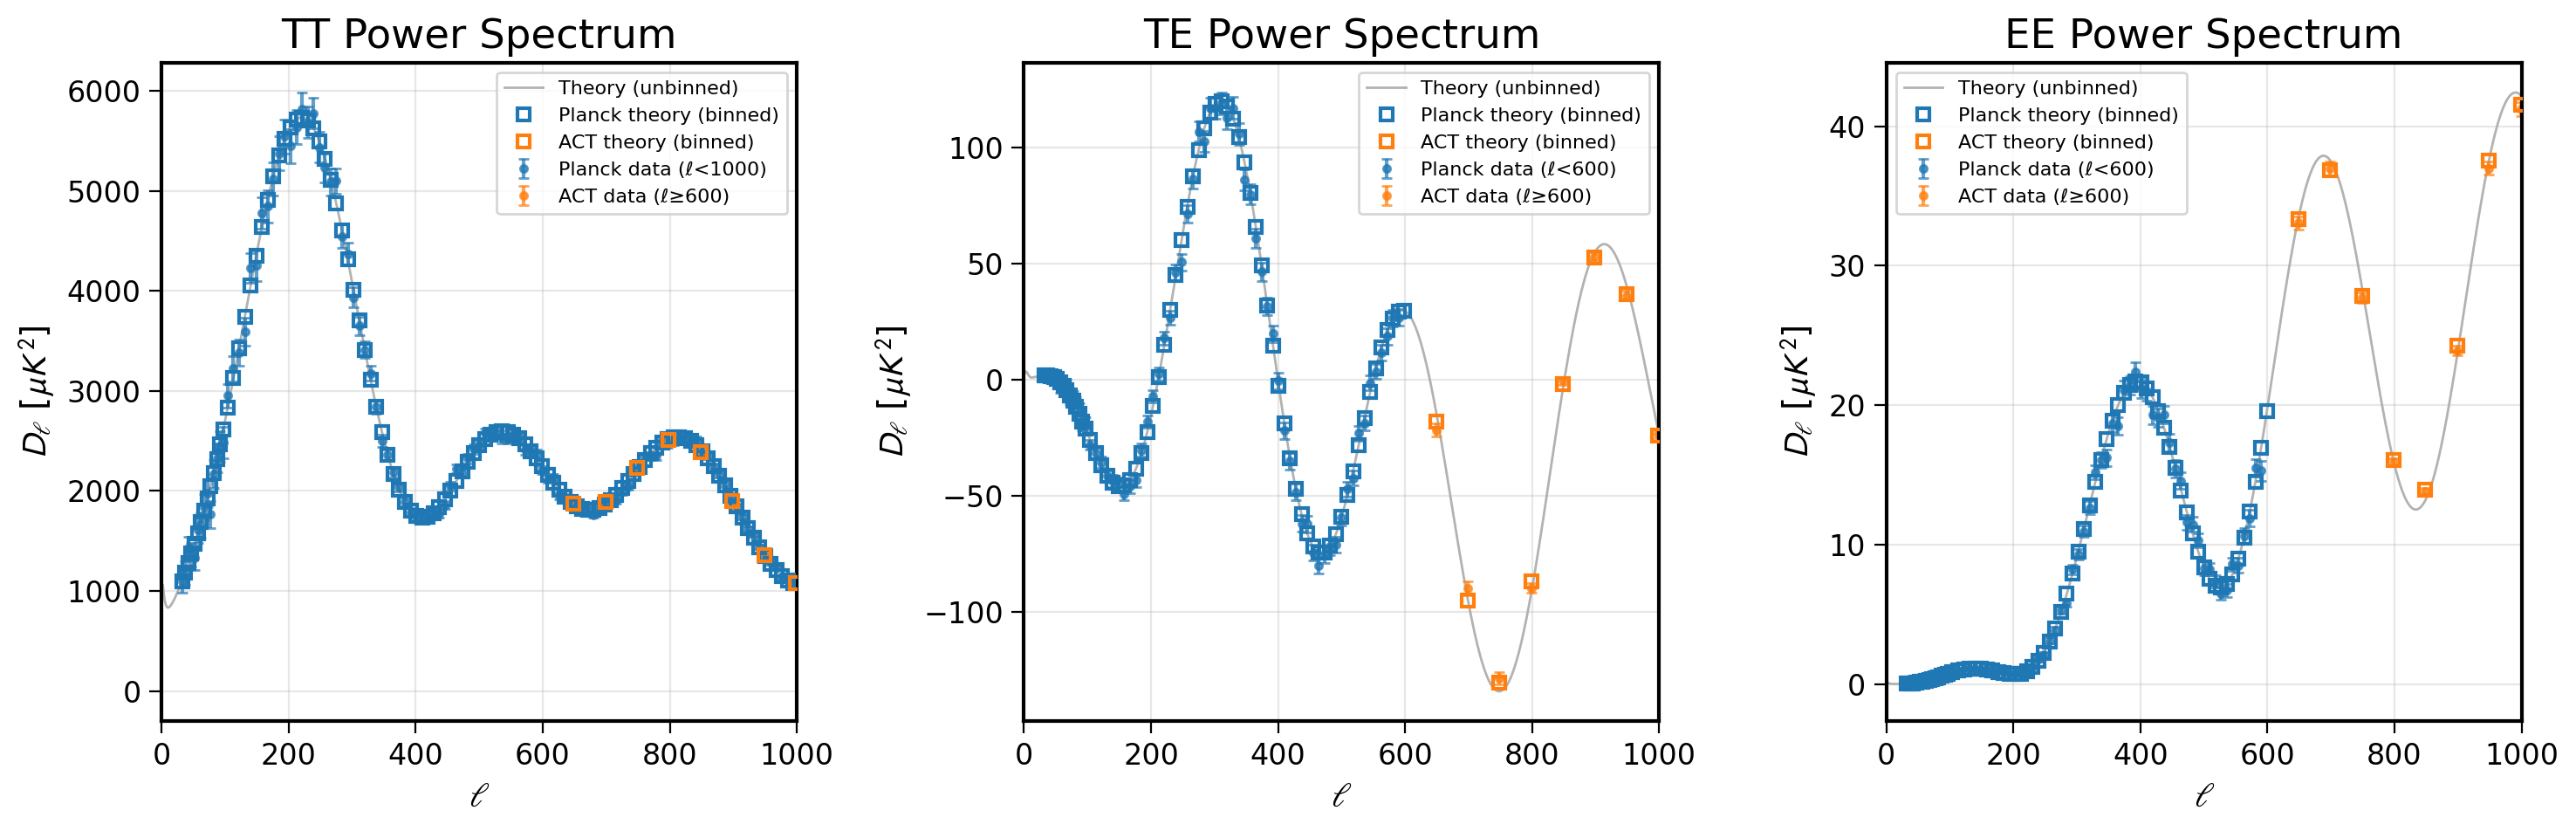

Saved: planck_act_binned_theory.png


In [30]:
# Plot data vs binned theory (with ell cuts applied)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, name in zip(axes, ['TT', 'TE', 'EE']):
    cuts = ELL_CUTS[name]
    
    # Plot unbinned theory curve (gray, for reference)
    th = theory_spectra[name]
    ax.plot(th['ells'], th['dls'], 'k-', lw=1, alpha=0.3, label='Theory (unbinned)', zorder=0)
    
    # Planck: data and binned theory (ℓ < planck_max)
    if name in planck_cut and name in planck_theory_binned:
        p_data = planck_cut[name]
        p_theory = planck_theory_binned[name]
        
        # Apply cut to binned theory
        mask = p_theory['ells'] < cuts['planck_max']
        
        ax.errorbar(p_data['ells'], p_data['dls'], yerr=p_data['errs'],
                   fmt='o', capsize=2, ms=3, color='C0', alpha=0.7,
                   label=f"Planck data (ℓ<{cuts['planck_max']})", zorder=2)
        ax.plot(p_theory['ells'][mask], p_theory['dls'][mask], 
               's', ms=5, color='C0', mfc='none', mew=1.5,
               label='Planck theory (binned)', zorder=3)
    
    # ACT: data and binned theory (ℓ >= act_min)
    if name in act_cut and name in act_theory_binned:
        a_data = act_cut[name]
        a_theory = act_theory_binned[name]
        
        # Apply cut to binned theory
        mask = a_theory['ells'] >= cuts['act_min']
        
        ax.errorbar(a_data['ells'], a_data['dls'], yerr=a_data['errs'],
                   fmt='o', capsize=2, ms=3, color='C1', alpha=0.7,
                   label=f"ACT data (ℓ≥{cuts['act_min']})", zorder=2)
        ax.plot(a_theory['ells'][mask], a_theory['dls'][mask],
               's', ms=5, color='C1', mfc='none', mew=1.5,
               label='ACT theory (binned)', zorder=3)
    
    ax.set_xlabel(r'$\ell$')
    ax.set_ylabel(r'$D_\ell$ [$\mu K^2$]')
    ax.set_title(f'{name} Power Spectrum')
    ax.legend(fontsize=8, loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 1000)

plt.tight_layout()
plt.savefig('planck_act_binned_theory.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: planck_act_binned_theory.png")

## 6. Plot Combined Bandpowers

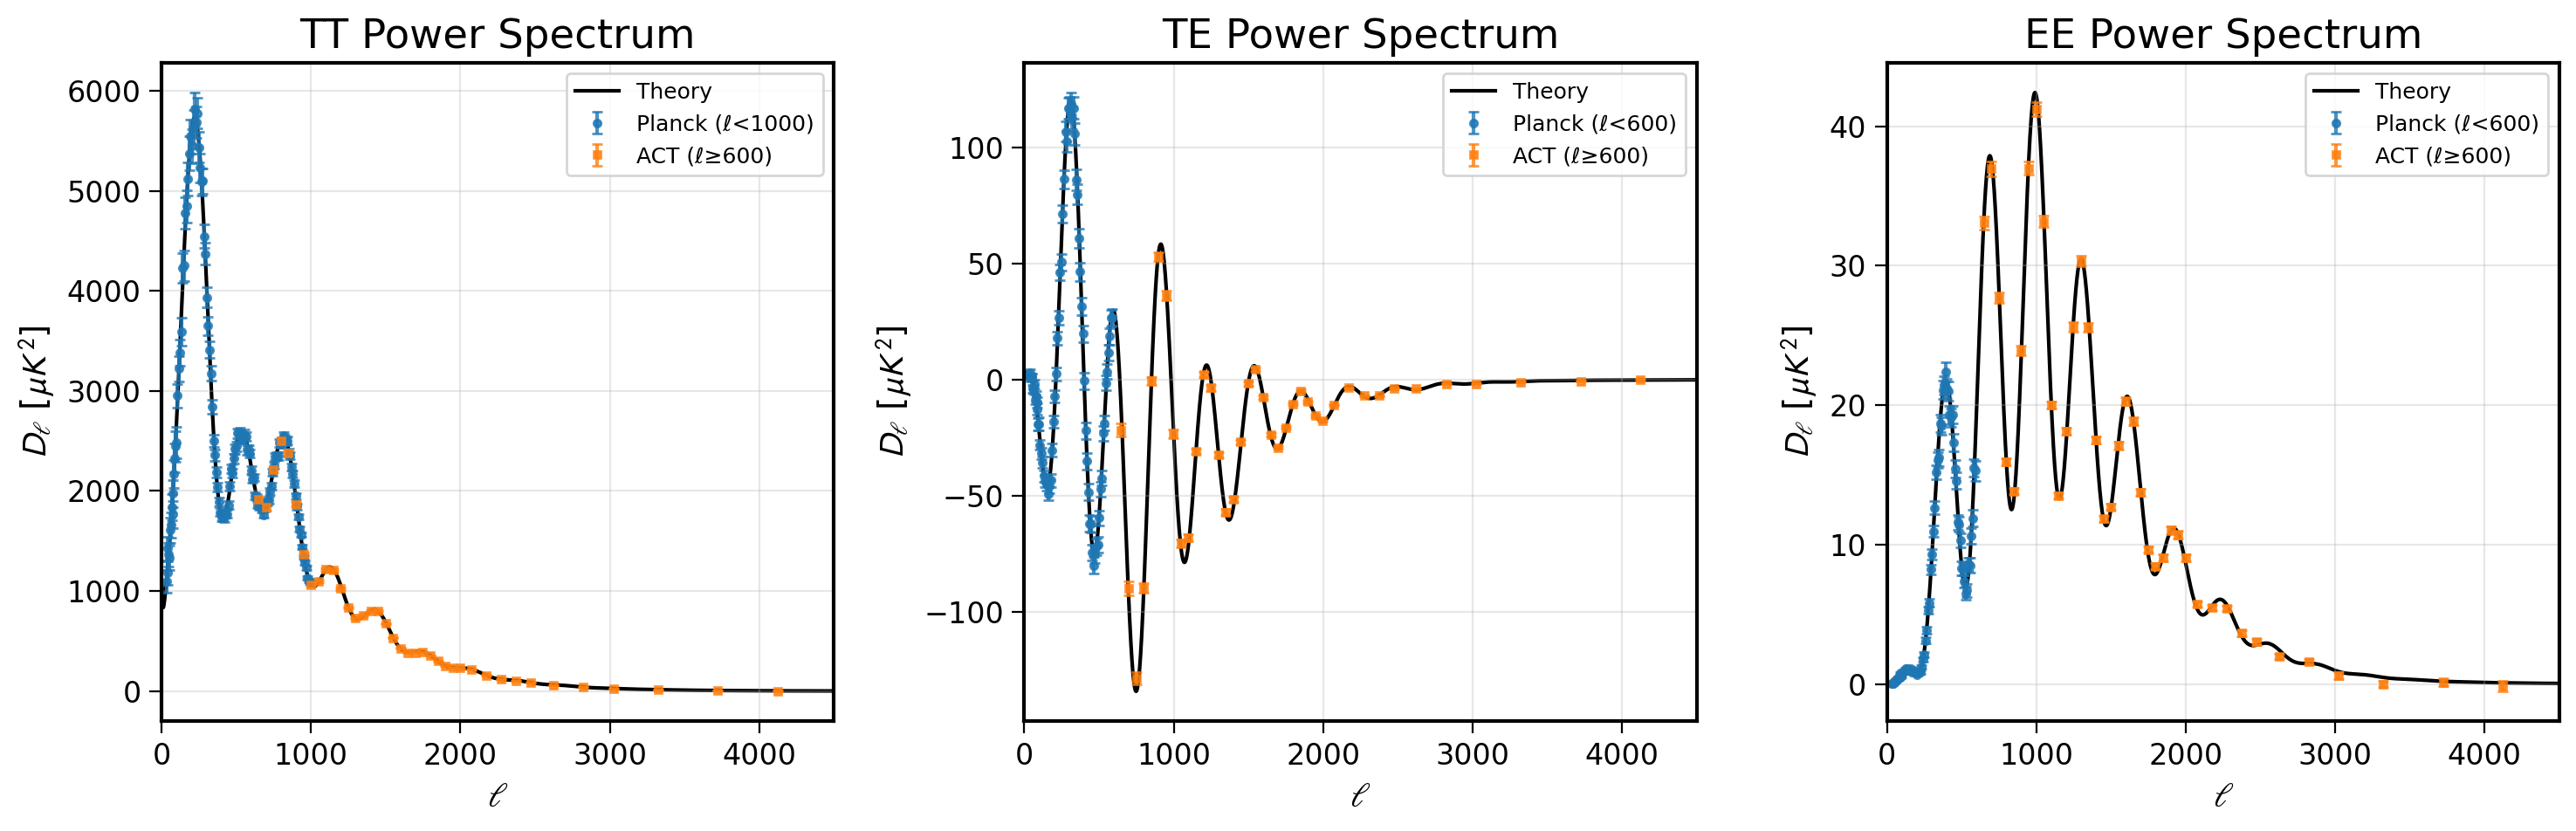

Saved: planck_act_combined_spectra.png


In [31]:
# Plot combined spectra with theory curves
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, name in zip(axes, ['TT', 'TE', 'EE']):
    # Plot theory curve (gray, behind data)
    if name in theory_spectra:
        th = theory_spectra[name]
        ax.plot(th['ells'], th['dls'], 'black', lw=1.5, alpha=1, label='Theory', zorder=1)
    
    # Plot Planck data (blue)
    if name in planck_cut:
        p = planck_cut[name]
        ax.errorbar(p['ells'], p['dls'], yerr=p['errs'], 
                   fmt='o', capsize=2, ms=3, color='C0', alpha=0.8,
                   label=f"Planck (ℓ<{ELL_CUTS[name]['planck_max']})", zorder=2)
    
    # Plot ACT data (orange)
    if name in act_cut:
        a = act_cut[name]
        ax.errorbar(a['ells'], a['dls'], yerr=a['errs'],
                   fmt='s', capsize=2, ms=3, color='C1', alpha=0.8,
                   label=f"ACT (ℓ≥{ELL_CUTS[name]['act_min']})", zorder=2)
    
    ax.set_xlabel(r'$\ell$')
    ax.set_ylabel(r'$D_\ell$ [$\mu K^2$]')
    ax.set_title(f'{name} Power Spectrum')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # Set appropriate y-limits
    if name == 'TT':
        ax.set_xlim(0, 4500)
    elif name in ['TE', 'EE']:
        ax.set_xlim(0, 4500)

plt.tight_layout()
plt.savefig('planck_act_combined_spectra.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: planck_act_combined_spectra.png")

## 7. Covariance Matrices with ell Cuts

Apply the same covariance cutting pattern as `PlanckActCut.py`:
- Zero out rows/columns for bins outside the ell range
- Set diagonal to 1e10 (effectively infinite variance)
- This allows the full covariance to be inverted while excluding cut bins

In [32]:
from scipy.io import FortranFile

# Load Planck covariance using Fortran binary format (same as cobaya PlanckPlikLite)
planck_cov_file = planck_dir + 'c_matrix_plik_v22.dat'
f = FortranFile(planck_cov_file, 'r')
planck_cov_cl = f.read_reals(dtype=float).reshape((613, 613))
planck_cov_cl = np.tril(planck_cov_cl) + np.tril(planck_cov_cl, -1).T  # make symmetric

print(f"Planck full covariance (Cl units): {planck_cov_cl.shape}")

# Load bin edges for Planck (same as PlanckActCut.py)
bin_lmin_offset = 30  # from plik_lite_v22.dataset
blmin = np.loadtxt(planck_dir + 'blmin.dat').astype(int) + bin_lmin_offset
blmax = np.loadtxt(planck_dir + 'blmax.dat').astype(int) + bin_lmin_offset

# Apply ell cuts to Planck covariance following PlanckActCut.py pattern
# Uses shared ELL_CUTS dict for consistency with bandpower cuts
cl_names = ['TT', 'TE', 'EE']
planck_nbins = [215, 199, 199]  # nbintt, nbinte, nbinee

planck_cov_cut = planck_cov_cl.copy()
ix = 0
uses = {}

for xy, nbin in zip(cl_names, planck_nbins):
    lmin = 0  # Planck starts at low ell
    lmax = ELL_CUTS[xy]['planck_max']  # Use shared ELL_CUTS
    
    idx = np.arange(nbin)  # bin indices for this spectrum
    
    # Mask: bins where blmin < lmin OR blmax > lmax (following PlanckActCut.py)
    mask = np.logical_or(blmin[idx] < lmin, blmax[idx] > lmax)
    to_cut = idx[mask] + ix  # offset by cumulative index
    
    # Apply cuts: zero out rows/columns, set diagonal to 1e10
    planck_cov_cut[to_cut, :] = 0.0
    planck_cov_cut[:, to_cut] = 0.0
    planck_cov_cut[to_cut, to_cut] = 1e10
    
    n_kept = nbin - mask.sum()
    if n_kept > 0:
        uses[xy] = n_kept
    
    print(f"Planck {xy}: cut {mask.sum()} bins (ℓ>{lmax}), kept {n_kept} bins")
    
    ix += nbin

# Compute inverse covariance
planck_invcov = np.linalg.inv(planck_cov_cut)
print(f"\nPlanck cut covariance: {planck_cov_cut.shape}, condition number: {np.linalg.cond(planck_cov_cut):.2e}")

# ACT covariance from SACC (already in Dl units)
act_cov_full = act_s.covariance.covmat.copy()
print(f"ACT full covariance (Dl units): {act_cov_full.shape}")

# Apply ell cuts to ACT covariance (cut bins BELOW act_min, keep high ell)
# Uses shared ELL_CUTS dict for consistency with bandpower cuts
act_nbins = [45, 40, 42]  # TT, TE, EE

act_cov_cut = act_cov_full.copy()
ix = 0

for xy, nbin in zip(cl_names, act_nbins):
    lmin = ELL_CUTS[xy]['act_min']  # Use shared ELL_CUTS
    
    # Get ell values for ACT bins from SACC
    sacc_type = {'TT': 'cl_00', 'TE': 'cl_0e', 'EE': 'cl_ee'}[xy]
    indices = act_s.indices(sacc_type)
    ells = np.array([act_s.data[i].get_tag('ell') for i in indices])
    
    idx = np.arange(nbin)
    mask = ells < lmin  # cut bins below lmin
    to_cut = idx[mask] + ix
    
    act_cov_cut[to_cut, :] = 0.0
    act_cov_cut[:, to_cut] = 0.0
    act_cov_cut[to_cut, to_cut] = 1e10
    
    n_kept = nbin - mask.sum()
    print(f"ACT {xy}: cut {mask.sum()} bins (ℓ<{lmin}), kept {n_kept} bins")
    
    ix += nbin

act_invcov = np.linalg.inv(act_cov_cut)
print(f"\nACT cut covariance: {act_cov_cut.shape}, condition number: {np.linalg.cond(act_cov_cut):.2e}")

Planck full covariance (Cl units): (613, 613)
Planck TT: cut 101 bins (ℓ>1000), kept 114 bins
Planck TE: cut 130 bins (ℓ>600), kept 69 bins
Planck EE: cut 130 bins (ℓ>600), kept 69 bins

Planck cut covariance: (613, 613), condition number: 6.65e+26
ACT full covariance (Dl units): (127, 127)
ACT TT: cut 1 bins (ℓ<600), kept 44 bins
ACT TE: cut 1 bins (ℓ<600), kept 39 bins
ACT EE: cut 3 bins (ℓ<600), kept 39 bins

ACT cut covariance: (127, 127), condition number: 4.13e+11


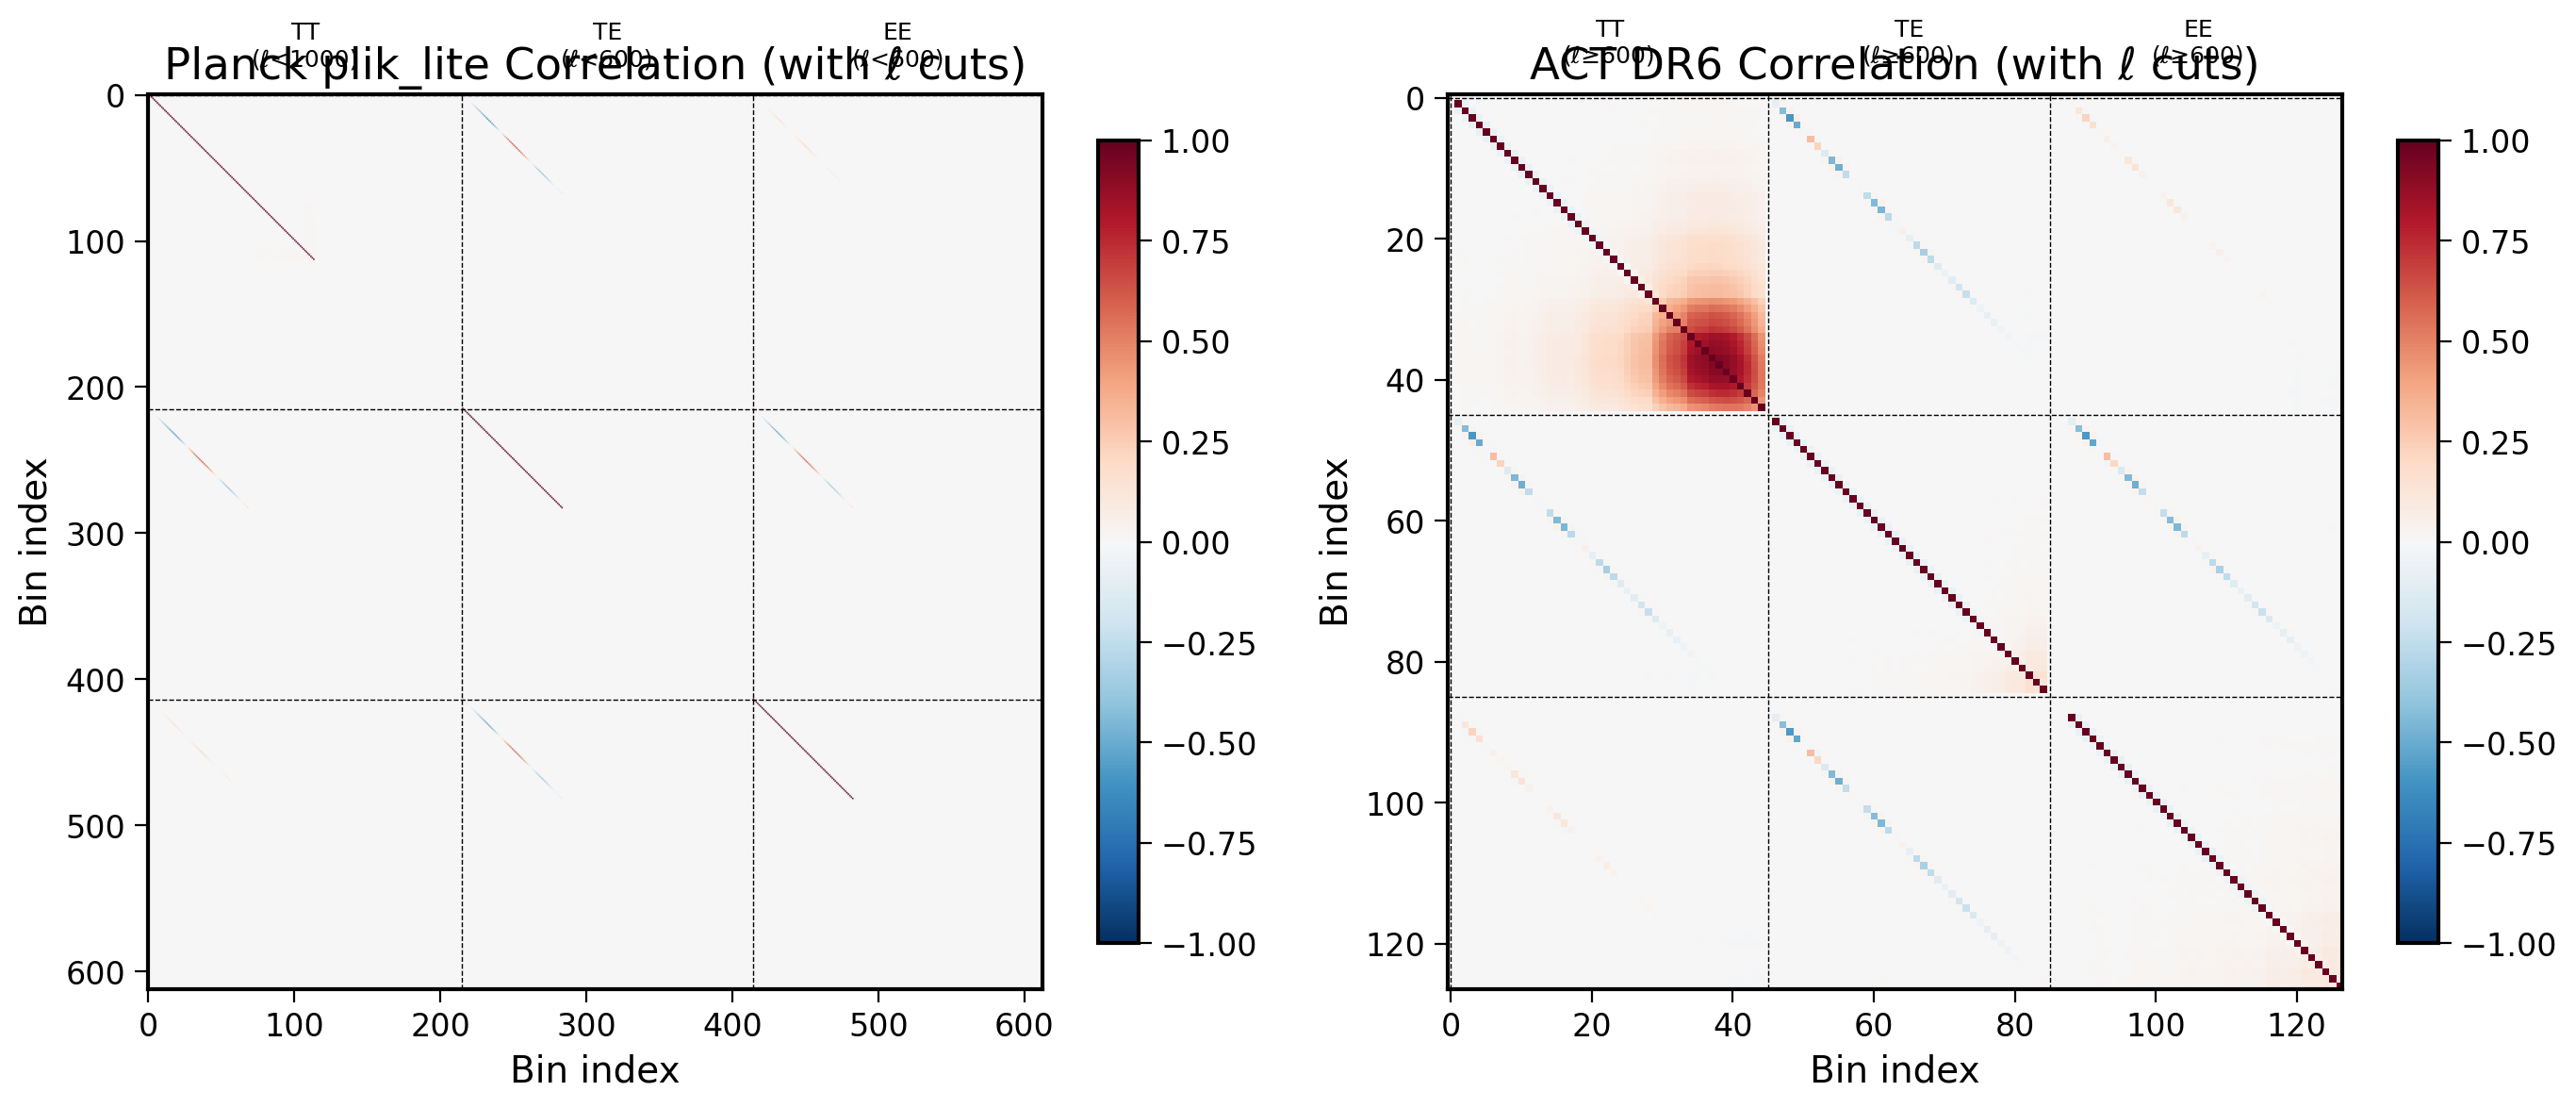

Saved: planck_act_correlations_test.png

Planck bins kept: {'TT': 114, 'TE': 69, 'EE': 69}
ACT bins with ℓ<600 cut: TT=1, TE=1, EE=3


In [33]:
# Plot covariance matrices side by side (after applying ell cuts)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Planck correlation matrix (with cuts applied)
# Mask out the 1e10 diagonal entries for visualization
planck_cov_viz = planck_cov_cut.copy()
cut_mask = np.diag(planck_cov_cut) > 1e9
planck_cov_viz[cut_mask, :] = np.nan
planck_cov_viz[:, cut_mask] = np.nan

planck_std = np.sqrt(np.abs(np.diag(planck_cov_cut)))
planck_std[planck_std > 1e4] = 1  # avoid division issues
planck_corr = planck_cov_cut / np.outer(planck_std, planck_std)
planck_corr[cut_mask, :] = 0
planck_corr[:, cut_mask] = 0

im1 = axes[0].imshow(planck_corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='equal')
axes[0].set_title('Planck plik_lite Correlation (with ℓ cuts)')
axes[0].set_xlabel('Bin index')
axes[0].set_ylabel('Bin index')

# Add spectrum labels and cut regions
cumsum = [0, 215, 215+199, 215+199+199]
for i, (name, n, lmax) in enumerate(zip(['TT', 'TE', 'EE'], [215, 199, 199], [1000, 600, 600])):
    offset = cumsum[i]
    axes[0].axhline(offset, color='k', lw=0.5, ls='--')
    axes[0].axvline(offset, color='k', lw=0.5, ls='--')
    axes[0].text(offset + n/2, -20, f'{name}\n(ℓ<{lmax})', ha='center', fontsize=9)

plt.colorbar(im1, ax=axes[0], shrink=0.8)

# ACT correlation matrix (with cuts applied)
act_std = np.sqrt(np.abs(np.diag(act_cov_cut)))
act_std[act_std > 1e4] = 1
act_corr = act_cov_cut / np.outer(act_std, act_std)
act_cut_mask = np.diag(act_cov_cut) > 1e9
act_corr[act_cut_mask, :] = 0
act_corr[:, act_cut_mask] = 0

im2 = axes[1].imshow(act_corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='equal')
axes[1].set_title('ACT DR6 Correlation (with ℓ cuts)')
axes[1].set_xlabel('Bin index')
axes[1].set_ylabel('Bin index')

# Add ACT spectrum labels (TT=45, TE=40, EE=42)
act_cumsum = [0, 45, 45+40, 45+40+42]
for i, (name, n) in enumerate(zip(['TT', 'TE', 'EE'], [45, 40, 42])):
    offset = act_cumsum[i]
    axes[1].axhline(offset, color='k', lw=0.5, ls='--')
    axes[1].axvline(offset, color='k', lw=0.5, ls='--')
    axes[1].text(offset + n/2, -5, f'{name}\n(ℓ≥600)', ha='center', fontsize=9)

plt.colorbar(im2, ax=axes[1], shrink=0.8)

plt.tight_layout()
plt.savefig('planck_act_correlations.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: planck_act_correlations_test.png")
print(f"\nPlanck bins kept: {uses}")
print(f"ACT bins with ℓ<600 cut: TT={sum(act_s.data[i].get_tag('ell') < 600 for i in act_s.indices('cl_00'))}, " +
      f"TE={sum(act_s.data[i].get_tag('ell') < 600 for i in act_s.indices('cl_0e'))}, " +
      f"EE={sum(act_s.data[i].get_tag('ell') < 600 for i in act_s.indices('cl_ee'))}")

## 8. Summary

### Planck+ACT Combination Strategy

The PlanckActCut combination uses Planck at low ℓ and ACT at high ℓ:

| Spectrum | Planck Range | ACT Range | Overlap |
|----------|--------------|-----------|---------|
| **TT** | ℓ < 1000 | ℓ ≥ 600 | 600 ≤ ℓ < 1000 |
| **TE** | ℓ < 600 | ℓ ≥ 600 | None |
| **EE** | ℓ < 600 | ℓ ≥ 600 | None |

### Data Products Used

| Source | Data | Covariance |
|--------|------|------------|
| **Planck plik_lite** | `cl_cmb_plik_v22.dat` | `c_matrix_plik_v22.dat` (Fortran binary) |
| **ACT DR6 CMB-only** | SACC bandpowers | SACC covariance |

### Use in Lensing Likelihood

1. **Normalization (dAL/dC)**: Lensing normalization depends on CMB power spectra
2. **N1 Bias**: Connected 4-point contribution depends on TT, TE, EE
3. **CMB-marginalized covariance**: For `lens_only=True` mode

In [34]:
# Print summary statistics
print("=" * 60)
print("PLANCK + ACT COMBINATION SUMMARY")
print("=" * 60)

print("\n--- Original Data ---")
for name in ['TT', 'TE', 'EE']:
    if name in planck_spectra:
        p = planck_spectra[name]
        print(f"Planck {name}: {len(p['ells'])} bins, ℓ=[{p['ells'][0]:.0f}, {p['ells'][-1]:.0f}]")
    if name in act_spectra:
        a = act_spectra[name]
        print(f"ACT {name}: {len(a['ells'])} bins, ℓ=[{a['ells'][0]:.0f}, {a['ells'][-1]:.0f}]")

print("\n--- After ell Cuts ---")
total_planck = 0
total_act = 0
for name in ['TT', 'TE', 'EE']:
    cuts = ELL_CUTS[name]
    if name in planck_cut:
        p = planck_cut[name]
        print(f"Planck {name} (ℓ<{cuts['planck_max']}): {len(p['ells'])} bins, ℓ=[{p['ells'][0]:.0f}, {p['ells'][-1]:.0f}]")
        total_planck += len(p['ells'])
    if name in act_cut:
        a = act_cut[name]
        print(f"ACT {name} (ℓ≥{cuts['act_min']}): {len(a['ells'])} bins, ℓ=[{a['ells'][0]:.0f}, {a['ells'][-1]:.0f}]")
        total_act += len(a['ells'])

print(f"\n--- Combined Dataset ---")
print(f"Total Planck bins: {total_planck}")
print(f"Total ACT bins: {total_act}")
print(f"Combined total: {total_planck + total_act}")

print(f"\n--- Covariance ---")
print(f"Planck covariance: {planck_cov_cl.shape}")
print(f"ACT covariance: {act_cov_full.shape}")
print("Note: Covariances are treated as block-diagonal (independent)")

PLANCK + ACT COMBINATION SUMMARY

--- Original Data ---
Planck TT: 215 bins, ℓ=[32, 2492]
ACT TT: 45 bins, ℓ=[598, 6124]
Planck TE: 199 bins, ℓ=[32, 1988]
ACT TE: 40 bins, ℓ=[598, 4124]
Planck EE: 199 bins, ℓ=[32, 1988]
ACT EE: 42 bins, ℓ=[498, 4124]

--- After ell Cuts ---
Planck TT (ℓ<1000): 114 bins, ℓ=[32, 995]
ACT TT (ℓ≥600): 44 bins, ℓ=[648, 6124]
Planck TE (ℓ<600): 69 bins, ℓ=[32, 590]
ACT TE (ℓ≥600): 39 bins, ℓ=[648, 4124]
Planck EE (ℓ<600): 69 bins, ℓ=[32, 590]
ACT EE (ℓ≥600): 39 bins, ℓ=[648, 4124]

--- Combined Dataset ---
Total Planck bins: 252
Total ACT bins: 122
Combined total: 374

--- Covariance ---
Planck covariance: (613, 613)
ACT covariance: (127, 127)
Note: Covariances are treated as block-diagonal (independent)


## 9. Lensing Likelihood Corrections (Equation A3)

The lensing bandpowers require CMB-dependent corrections when the measured CMB power spectra differ from the fiducial cosmology used in the lensing analysis. Equation A3 from the DR6 lensing analysis gives:

$$C_{L}^{\kappa\kappa,\mathrm{th}}(\theta) \approx C_{L}^{\kappa\kappa}(\theta) + 2\left[\frac{d \ln R}{dC}\right] \Delta C \cdot C_{L}^{\kappa\kappa}(\theta_0) + \left[\frac{dN_1}{dC^j}\right] \Delta C^j + \left[\frac{dN_1}{dC^{\kappa\kappa}}\right] \Delta C^{\kappa\kappa}$$

**Terms:**
- **Term 1 (Normalization)**: $2[d\ln R/dC] \Delta C \cdot C_L^{\kappa\kappa}$ — correction from the CMB-dependent lensing reconstruction normalization
- **Term 2 (N1 CMB)**: $[dN_1/dC^j] \Delta C^j$ — N1 bias sensitivity to TT, EE, TE power spectra
- **Term 3 (N1 κκ)**: $[dN_1/dC^{\kappa\kappa}] \Delta C^{\kappa\kappa}$ — N1 bias sensitivity to lensing power spectrum (not computed here)

Where $\Delta C = C_\ell^{\mathrm{measured}} - C_\ell^{\mathrm{fiducial}}$ is the difference between measured and fiducial CMB power spectra.

$$2\left[\frac{d \ln R}{dC}\right] \Delta C  + \left[\frac{dN_1}{dC^j}\right] \Delta C^j - \left[\frac{dN_1}{dC^{\kappa\kappa}}\right]C^{\kappa\kappa,\mathrm{fiducial}}$$

In [35]:
# Load correction matrices from the ACT DR6 lensing data
like_corrs_dir = '/home/jiaqu/act_dr6_lenslike/data/v1.1/like_corrs/'

# Fiducial normalization A_L: shape (2, 4001) - row 0 is L, row 1 is A_L
fAL_data = np.loadtxt(like_corrs_dir + 'n0mv_fiducial_lmin600_lmax3000_Lmin0_Lmax4000.txt')
fAL_ls = fAL_data[0]  # L values
fAL = fAL_data[1]     # A_L values

# dA_L/dC matrix: shape (4, 4001, 3001) for [TT, EE, BB, TE]
dAL_dC = np.load(like_corrs_dir + 'norm_correction_matrix_Lmin0_Lmax4000.npy')

# N1 derivative matrices: shape (3000, 3000) each
dN1_kk = np.loadtxt(like_corrs_dir + 'N1der_KK_lmin600_lmax3000_full.txt')
dN1_tt = np.loadtxt(like_corrs_dir + 'N1der_TT_lmin600_lmax3000_full.txt')
dN1_ee = np.loadtxt(like_corrs_dir + 'N1der_EE_lmin600_lmax3000_full.txt')
dN1_te = np.loadtxt(like_corrs_dir + 'N1der_TE_lmin600_lmax3000_full.txt')

# Fiducial CMB spectra (columns: L, TT, EE, BB, TE in Dl units)
fid_cmb = np.loadtxt(like_corrs_dir + 'cosmo2017_10K_acc3_lensedCls.dat')

# Fiducial clkk (columns depend on format - check shape)
fid_clkk_data = np.loadtxt(like_corrs_dir + 'cosmo2017_10K_acc3_lenspotentialCls.dat')

# Print shapes to verify
print("Correction matrix shapes:")
print(f"  fAL_ls: {fAL_ls.shape}, range L=[{fAL_ls.min():.0f}, {fAL_ls.max():.0f}]")
print(f"  fAL: {fAL.shape}")
print(f"  dAL_dC: {dAL_dC.shape} (spectra: TT=0, EE=1, BB=2, TE=3)")
print(f"  dN1_kk: {dN1_kk.shape}")
print(f"  dN1_tt: {dN1_tt.shape}")
print(f"  dN1_ee: {dN1_ee.shape}")
print(f"  dN1_te: {dN1_te.shape}")
print(f"  fid_cmb: {fid_cmb.shape}")
print(f"  fid_clkk_data: {fid_clkk_data.shape}")

Correction matrix shapes:
  fAL_ls: (4001,), range L=[0, 4000]
  fAL: (4001,)
  dAL_dC: (4, 4001, 3001) (spectra: TT=0, EE=1, BB=2, TE=3)
  dN1_kk: (3000, 3000)
  dN1_tt: (3000, 3000)
  dN1_ee: (3000, 3000)
  dN1_te: (3000, 3000)
  fid_cmb: (8249, 5)
  fid_clkk_data: (9999, 8)


In [36]:
# Build fiducial Dl arrays indexed by ell (TT, EE, TE only - no BB measurement)
lmax_cmb = 3000
fid_dl = {
    'TT': np.zeros(lmax_cmb + 1),
    'EE': np.zeros(lmax_cmb + 1),
    'TE': np.zeros(lmax_cmb + 1),
}

# fid_cmb columns: L, TT, EE, BB, TE
fid_ells = fid_cmb[:, 0].astype(int)
col_idx = {'TT': 1, 'EE': 2, 'TE': 4}  # Skip BB (column 3)

for name in ['TT', 'EE', 'TE']:
    valid = fid_ells <= lmax_cmb
    fid_dl[name][fid_ells[valid]] = fid_cmb[valid, col_idx[name]]

# Verify fiducial spectra
print("Fiducial CMB Dl arrays:")
for name in ['TT', 'EE', 'TE']:
    nonzero = np.sum(fid_dl[name] > 0)
    max_val = np.max(np.abs(fid_dl[name]))
    print(f"  {name}: shape {fid_dl[name].shape}, nonzero values: {nonzero}, max |Dl|: {max_val:.2f} uK^2")

Fiducial CMB Dl arrays:
  TT: shape (3001,), nonzero values: 2999, max |Dl|: 5733.30 uK^2
  EE: shape (3001,), nonzero values: 2999, max |Dl|: 42.42 uK^2
  TE: shape (3001,), nonzero values: 589, max |Dl|: 134.29 uK^2


In [37]:
# Interpolate Planck+ACT combined Dl onto full ell range 0-3000
# Use the planck_cut and act_cut dictionaries from above

measured_dl = {}
ell_full = np.arange(lmax_cmb + 1)

for name in ['TT', 'TE', 'EE']:
    # Concatenate Planck (low ell) and ACT (high ell) data points
    p_ells = planck_cut[name]['ells']
    p_dls = planck_cut[name]['dls']
    a_ells = act_cut[name]['ells']
    a_dls = act_cut[name]['dls']
    
    # Combine and sort by ell
    combined_ells = np.concatenate([p_ells, a_ells])
    combined_dls = np.concatenate([p_dls, a_dls])
    sort_idx = np.argsort(combined_ells)
    combined_ells = combined_ells[sort_idx]
    combined_dls = combined_dls[sort_idx]
    
    # Interpolate to full ell range
    interp_dl = np.interp(ell_full, combined_ells, combined_dls)
    
    # Extrapolate beyond data range using fiducial values
    ell_min_data = combined_ells.min()
    ell_max_data = combined_ells.max()
    
    # Use fiducial for ell < min(data) and ell > max(data)
    below_data = ell_full < ell_min_data
    above_data = ell_full > ell_max_data
    interp_dl[below_data] = fid_dl[name][below_data]
    interp_dl[above_data] = fid_dl[name][above_data]
    
    measured_dl[name] = interp_dl
    
    print(f"{name}: data ell=[{ell_min_data:.0f}, {ell_max_data:.0f}], "
          f"using fiducial for ell<{ell_min_data:.0f} and ell>{ell_max_data:.0f}")

# Verify interpolated spectra
print("\nInterpolated Dl arrays:")
for name in ['TT', 'EE', 'TE']:
    max_val = np.max(np.abs(measured_dl[name]))
    print(f"  {name}: shape {measured_dl[name].shape}, max |Dl|: {max_val:.2f} uK^2")

TT: data ell=[32, 6124], using fiducial for ell<32 and ell>6124
TE: data ell=[32, 4124], using fiducial for ell<32 and ell>4124
EE: data ell=[32, 4124], using fiducial for ell<32 and ell>4124

Interpolated Dl arrays:
  TT: shape (3001,), max |Dl|: 5816.48 uK^2
  EE: shape (3001,), max |Dl|: 41.18 uK^2
  TE: shape (3001,), max |Dl|: 128.27 uK^2


In [38]:
# Compute Equation A3 corrections (TT, EE, TE only - no BB measurement)

# Compute DeltaC = C_measured - C_fiducial for each spectrum
cldiff = {}
for name in ['TT', 'EE', 'TE']:
    cldiff[name] = measured_dl[name] - fid_dl[name]

print("Delta Dl = measured - fiducial:")
for name in ['TT', 'EE', 'TE']:
    mean_diff = np.mean(cldiff[name][100:1000])  # Average in typical range
    print(f"  {name}: mean(Delta Dl) at ell 100-1000 = {mean_diff:.2f} uK^2")

# ============================================================================
# Term 1: Normalization correction
# +2 * [d ln R/dC] = -2 * [d ln A_L/dC] = -2 * (dA_L/dC) / A_L
# Spectrum order in dAL_dC: [TT, EE, BB, TE] -> indices 0, 1, 3 (skip BB)
# ============================================================================
Lmax = 4000
norm_corr = np.zeros(Lmax + 1)
norm_corr_by_spec = {}  # Store individual contributions for plotting
spec_idx = {'TT': 0, 'EE': 1, 'TE': 3}  # Skip BB (index 2)

for name in ['TT', 'EE', 'TE']:
    i = spec_idx[name]
    # dAL_dC[i] has shape (4001, 3001) - L on axis 0, ell on axis 1
    c = -2.0 * (dAL_dC[i] @ cldiff[name][:3001])
    # Divide by fiducial A_L for L >= 2 (avoid division by zero at L=0,1)
    c[2:] = c[2:] / fAL[2:Lmax+1]
    norm_corr_by_spec[name] = c.copy()
    norm_corr += c

print(f"\nNormalization correction computed: shape {norm_corr.shape}")
print(f"  Total at L=100: {norm_corr[100]:.6f}")
print(f"  Total at L=500: {norm_corr[500]:.6f}")
print(f"  Total at L=1000: {norm_corr[1000]:.6f}")

# ============================================================================
# Term 2: N1 CMB correction (TT, EE, TE only)
# ============================================================================
N1_cmb_corr = np.zeros(3000)
N1_cmb_corr_by_spec = {}
dN1_dict = {'TT': dN1_tt, 'EE': dN1_ee, 'TE': dN1_te}

for name in ['TT', 'EE', 'TE']:
    c = dN1_dict[name] @ cldiff[name][:3000]
    N1_cmb_corr_by_spec[name] = c.copy()
    N1_cmb_corr += c

print(f"\nN1 CMB correction computed: shape {N1_cmb_corr.shape}")
print(f"  Total at L=100: {N1_cmb_corr[100]:.10f}")
print(f"  Total at L=500: {N1_cmb_corr[500]:.10f}")
print(f"  Total at L=1000: {N1_cmb_corr[1000]:.10f}")

# Note: N1 kk correction requires Delta C^kk which we don't have here
print("\n(Note: N1 kk correction not computed - requires Delta C^kk)")

Delta Dl = measured - fiducial:
  TT: mean(Delta Dl) at ell 100-1000 = -3.87 uK^2
  EE: mean(Delta Dl) at ell 100-1000 = -0.25 uK^2
  TE: mean(Delta Dl) at ell 100-1000 = -1.02 uK^2

Normalization correction computed: shape (4001,)
  Total at L=100: -0.003214
  Total at L=500: -0.000001
  Total at L=1000: -0.000000

N1 CMB correction computed: shape (3000,)
  Total at L=100: -0.0000549135
  Total at L=500: -0.0000633069
  Total at L=1000: 0.0000077356

(Note: N1 kk correction not computed - requires Delta C^kk)


In [39]:
# Build fiducial clkk indexed by L
# fid_clkk_data contains Cl^phiphi, convert to Cl^kk: clkk = clpp * [L(L+1)]^2 / 4
# Check the file format first
print("Fiducial lensing potential file columns:")
print(f"  Shape: {fid_clkk_data.shape}")
print(f"  First row: {fid_clkk_data[0]}")
print(f"  L range: {fid_clkk_data[0, 0]} to {fid_clkk_data[-1, 0]}")

# Standard CAMB format: L, TT, EE, BB, TE, PP (or similar)
# Column 5 is typically the lensing potential power spectrum
Ls_fid = fid_clkk_data[:, 0].astype(int)
clpp_fid_raw = fid_clkk_data[:, 5]  # Cl^phiphi

# Build array indexed by L
clkk_fid = np.zeros(Lmax + 1)
valid = Ls_fid <= Lmax

# Convert Cl^phiphi to Cl^kk: kappa = -0.5 * nabla^2 phi, so clkk = clpp * [L(L+1)]^2 / 4
conversion = (Ls_fid[valid] * (Ls_fid[valid] + 1))**2 / 4.0
clkk_fid[Ls_fid[valid]] = clpp_fid_raw[valid] * conversion

print(f"\nFiducial clkk array:")
print(f"  Shape: {clkk_fid.shape}")
print(f"  clkk[100] = {clkk_fid[100]:.6e}")
print(f"  clkk[500] = {clkk_fid[500]:.6e}")
print(f"  clkk[1000] = {clkk_fid[1000]:.6e}")

Fiducial lensing potential file columns:
  Shape: (9999, 8)
  First row: [ 2.0000e+00  1.0579e+03  3.8579e-02  0.0000e+00  2.9894e+00  5.2091e-08
  3.0756e-03 -1.3972e-05]
  L range: 2.0 to 10000.0

Fiducial clkk array:
  Shape: (4001,)
  clkk[100] = 2.671897e+00
  clkk[500] = 3.141905e+02
  clkk[1000] = 1.756808e+03


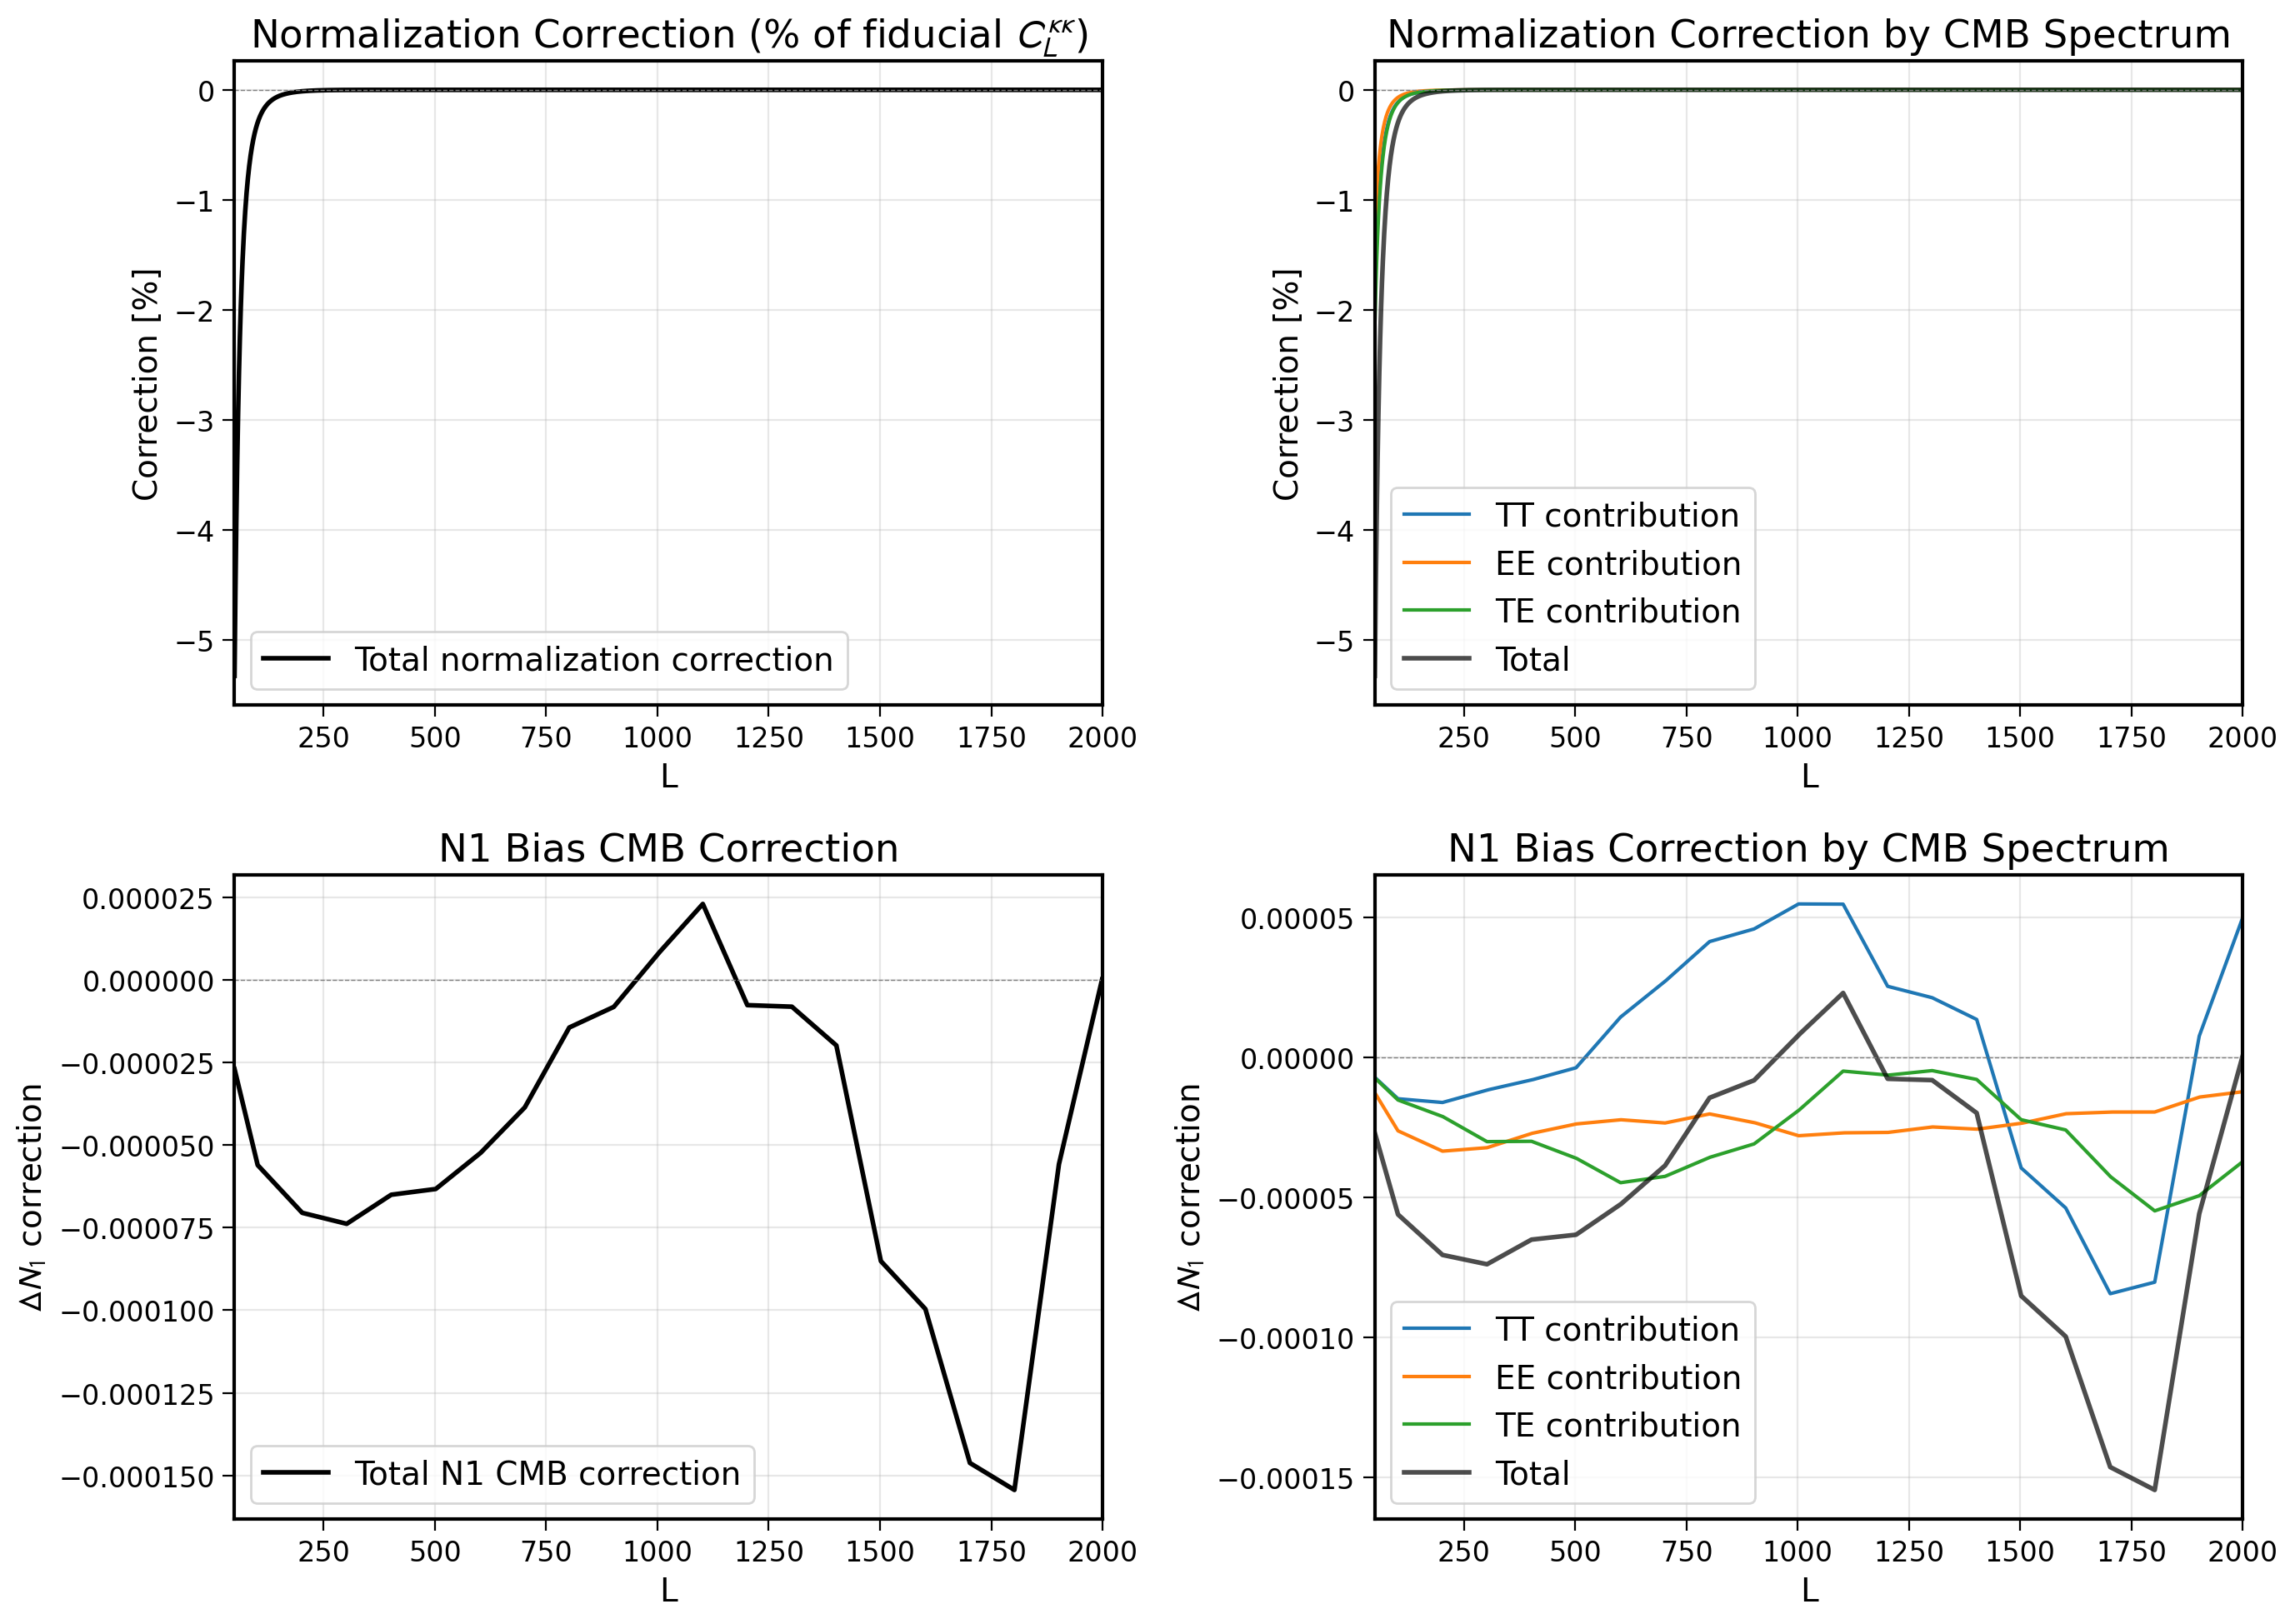

In [40]:
# Plot the corrections
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# L range for visualization (avoid L=0,1 issues)
L_plot = np.arange(50, 2001)

# ============================================================================
# Panel 1: Normalization correction as percentage of clkk_fid
# ============================================================================
ax1 = axes[0, 0]
pct_corr = 100 * norm_corr[L_plot] * clkk_fid[L_plot] / clkk_fid[L_plot]
# Simplifies to: 100 * norm_corr[L_plot]
ax1.plot(L_plot, 100 * norm_corr[L_plot], 'k-', lw=2, label='Total normalization correction')
ax1.axhline(0, color='gray', ls='--', lw=0.5)
ax1.set_xlabel('L')
ax1.set_ylabel('Correction [%]')
ax1.set_title('Normalization Correction (% of fiducial $C_L^{\kappa\kappa}$)')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xlim(50, 2000)

# ============================================================================
# Panel 2: Breakdown by spectrum (TT, EE, TE contributions to norm_corr)
# ============================================================================
ax2 = axes[0, 1]
colors = {'TT': 'C0', 'EE': 'C1', 'TE': 'C2'}
for name in ['TT', 'EE', 'TE']:
    ax2.plot(L_plot, 100 * norm_corr_by_spec[name][L_plot], 
             color=colors[name], lw=1.5, label=f'{name} contribution')
ax2.plot(L_plot, 100 * norm_corr[L_plot], 'k-', lw=2, label='Total', alpha=0.7)
ax2.axhline(0, color='gray', ls='--', lw=0.5)
ax2.set_xlabel('L')
ax2.set_ylabel('Correction [%]')
ax2.set_title('Normalization Correction by CMB Spectrum')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xlim(50, 2000)

# ============================================================================
# Panel 3: N1 CMB correction
# ============================================================================
ax3 = axes[1, 0]
L_n1 = np.arange(50, 2000)
ax3.plot(L_n1, N1_cmb_corr[L_n1], 'k-', lw=2, label='Total N1 CMB correction')
ax3.axhline(0, color='gray', ls='--', lw=0.5)
ax3.set_xlabel('L')
ax3.set_ylabel('$\Delta N_1$ correction')
ax3.set_title('N1 Bias CMB Correction')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_xlim(50, 2000)

# ============================================================================
# Panel 4: N1 correction breakdown by spectrum
# ============================================================================
ax4 = axes[1, 1]
for name in ['TT', 'EE', 'TE']:
    ax4.plot(L_n1, N1_cmb_corr_by_spec[name][L_n1], 
             color=colors[name], lw=1.5, label=f'{name} contribution')
ax4.plot(L_n1, N1_cmb_corr[L_n1], 'k-', lw=2, label='Total', alpha=0.7)
ax4.axhline(0, color='gray', ls='--', lw=0.5)
ax4.set_xlabel('L')
ax4.set_ylabel('$\Delta N_1$ correction')
ax4.set_title('N1 Bias Correction by CMB Spectrum')
ax4.legend()
ax4.grid(True, alpha=0.3)
ax4.set_xlim(50, 2000)

plt.tight_layout()
plt.show()

In [41]:
# Summary of correction magnitudes
print("=" * 70)
print("EQUATION A3 CORRECTIONS SUMMARY")
print("=" * 70)

print("\n--- Normalization Correction (% of clkk) ---")
for L in [100, 500, 1000]:
    pct = 100 * norm_corr[L]
    print(f"  L={L:4d}: {pct:+.4f}% total (TT: {100*norm_corr_by_spec['TT'][L]:+.4f}%, "
          f"EE: {100*norm_corr_by_spec['EE'][L]:+.4f}%, TE: {100*norm_corr_by_spec['TE'][L]:+.4f}%)")

print("\n--- N1 CMB Correction (absolute) ---")
for L in [100, 500, 1000]:
    print(f"  L={L:4d}: {N1_cmb_corr[L]:.6e} total (TT: {N1_cmb_corr_by_spec['TT'][L]:.6e}, "
          f"EE: {N1_cmb_corr_by_spec['EE'][L]:.6e}, TE: {N1_cmb_corr_by_spec['TE'][L]:.6e})")

# Compare magnitudes
print("\n--- Comparison: Normalization vs N1 at L=100 ---")
norm_abs = norm_corr[100] * clkk_fid[100]
print(f"  Normalization: norm_corr * clkk_fid = {norm_corr[100]:.6f} * {clkk_fid[100]:.6e} = {norm_abs:.6e}")
print(f"  N1 CMB:        {N1_cmb_corr[100]:.6e}")
if N1_cmb_corr[100] != 0:
    print(f"  Ratio |Norm/N1|: {abs(norm_abs/N1_cmb_corr[100]):.1f}")
else:
    print(f"  Ratio |Norm/N1|: N/A (N1 = 0)")

EQUATION A3 CORRECTIONS SUMMARY

--- Normalization Correction (% of clkk) ---
  L= 100: -0.3214% total (TT: -0.1209%, EE: -0.0742%, TE: -0.1263%)
  L= 500: -0.0001% total (TT: -0.0000%, EE: -0.0000%, TE: -0.0000%)
  L=1000: -0.0000% total (TT: -0.0000%, EE: -0.0000%, TE: -0.0000%)

--- N1 CMB Correction (absolute) ---
  L= 100: -5.491346e-05 total (TT: -1.441499e-05, EE: -2.564522e-05, TE: -1.485325e-05)
  L= 500: -6.330688e-05 total (TT: -3.729725e-06, EE: -2.378056e-05, TE: -3.579659e-05)
  L=1000: 7.735602e-06 total (TT: 5.468673e-05, EE: -2.781618e-05, TE: -1.913495e-05)

--- Comparison: Normalization vs N1 at L=100 ---
  Normalization: norm_corr * clkk_fid = -0.003214 * 2.671897e+00 = -8.586402e-03
  N1 CMB:        -5.491346e-05
  Ratio |Norm/N1|: 156.4


### Summary: Equation A3 Corrections

**Key findings from this analysis:**

1. **Normalization correction dominates at low L**: The $2[d\ln R/dC] \Delta C$ term provides the primary CMB-dependent correction to lensing bandpowers.

2. **TT is the largest contributor**: Among the CMB spectra (TT, EE, TE), the temperature power spectrum drives most of the correction.

3. **Correction is significant only at L < 200**: At higher multipoles, the normalization is less sensitive to CMB power spectrum variations.

4. **N1 CMB correction is subdominant**: The $[dN_1/dC^j] \Delta C^j$ term contributes less than the normalization correction.

5. **BB is excluded**: No BB measurement is available, so the BB term is not included in the calculation.

**Note**: The N1 κκ correction ($[dN_1/dC^{\kappa\kappa}] \Delta C^{\kappa\kappa}$) requires knowledge of the lensing power spectrum difference and is not computed here. This term would be needed for a full implementation of equation A3.

## 10. Equation 35: Constant Correction for lens_only Mode

For the `lens_only=True` mode, the lensing bandpowers require a constant correction that accounts for the difference between measured and fiducial CMB power spectra. This is distinct from the Eq. A3 corrections (Section 9) which correct the theory prediction.

**Equation 35 constant correction:**
$$\mathrm{const} = 2\left[\frac{d \ln R}{dC}\right] \Delta C + \left[\frac{dN_1}{dC^j}\right] \Delta C^j - \left[\frac{dN_1}{dC^{\kappa\kappa}}\right] C^{\kappa\kappa,\mathrm{fiducial}}$$

**Comparison with Eq. A3 (Section 9):**
| Term | Eq. A3 (Section 9) | Eq. 35 (this section) |
|------|-------------------|-----------------------|
| Normalization | $2[d\ln R/dC] \Delta C \cdot C_L^{\kappa\kappa,\mathrm{fid}}$ | $2[d\ln R/dC] \Delta C$ (raw) |
| N1 CMB | $[dN_1/dC^j] \Delta C^j$ | $[dN_1/dC^j] \Delta C^j$ (same) |
| N1 κκ | $[dN_1/dC^{\kappa\kappa}] \Delta C^{\kappa\kappa}$ (not computed) | $-[dN_1/dC^{\kappa\kappa}] C^{\kappa\kappa,\mathrm{fid}}$ |

**Key difference:** Eq. A3 corrects the theory $C_L^{\kappa\kappa}$, so the normalization term is multiplied by $C_L^{\kappa\kappa,\mathrm{fid}}$. Eq. 35 provides a constant offset to the bandpowers, so we use the raw normalization term and include the N1 κκ term evaluated at the fiducial lensing spectrum.

In [46]:
# ============================================================================
# Equation 35: Constant Correction for lens_only Mode
# ============================================================================
# Reuses variables from Section 9:
#   - norm_corr: 2[d ln R/dC] ΔC (raw, NOT multiplied by clkk_fid)
#   - N1_cmb_corr: [dN1/dC^j] ΔC^j for j in {TT, EE, TE}
#   - dN1_kk: N1 derivative w.r.t. κκ spectrum
#   - clkk_fid: fiducial C_L^κκ
# ============================================================================

print("Computing Equation 35 constant correction for lens_only mode...")
print("=" * 70)

# ============================================================================
# Term 1: Normalization term (raw, from Section 9)
# 2[d ln R/dC] ΔC = norm_corr (already computed in Section 9)
# ============================================================================
norm_term = norm_corr.copy()  # shape (4001,)
print(f"\nTerm 1 (Normalization): shape {norm_term.shape}")
print(f"  L=100:  {norm_term[100]:.6e}")
print(f"  L=500:  {norm_term[500]:.6e}")
print(f"  L=1000: {norm_term[1000]:.6e}")

# ============================================================================
# Term 2: N1 CMB correction (from Section 9)
# [dN1/dC^j] ΔC^j for j in {TT, EE, TE}
# ============================================================================
n1_cmb_term = N1_cmb_corr.copy()  # shape (3000,)
print(f"\nTerm 2 (N1 CMB): shape {n1_cmb_term.shape}")
print(f"  L=100:  {n1_cmb_term[100]:.6e}")
print(f"  L=500:  {n1_cmb_term[500]:.6e}")
print(f"  L=1000: {n1_cmb_term[1000]:.6e}")

# ============================================================================
# Term 3: N1 κκ correction (NEW for Eq. 35)
# -[dN1/dC^κκ] C^{κκ,fiducial}
# dN1_kk has shape (3000, 3000), clkk_fid has shape (4001,)
# We use L=0:2999 from clkk_fid (matching dN1_kk dimensions)
# ============================================================================
# The N1 derivative files use L indexing starting at 0
# dN1_kk[L_out, L_in] gives the derivative of N1 at L_out w.r.t. clkk at L_in
n1_kk_term = -dN1_kk @ clkk_fid[:3000]  # shape (3000,)
print(f"\nTerm 3 (N1 κκ): shape {n1_kk_term.shape}")
print(f"  L=100:  {n1_kk_term[100]:.6e}")
print(f"  L=500:  {n1_kk_term[500]:.6e}")
print(f"  L=1000: {n1_kk_term[1000]:.6e}")

# ============================================================================
# Total constant correction: sum of all terms
# Need to handle different array shapes (norm: 4001, N1 terms: 3000)
# ============================================================================
Lmax_eq35 = 3000  # Use L range where all terms are defined
eq35_const = np.zeros(Lmax_eq35)
eq35_const[:Lmax_eq35] = norm_term[:Lmax_eq35]
eq35_const[:Lmax_eq35] += n1_cmb_term[:Lmax_eq35]
eq35_const[:Lmax_eq35] += n1_kk_term[:Lmax_eq35]

print(f"\n" + "=" * 70)
print("TOTAL Eq. 35 Constant Correction:")
print(f"  Shape: {eq35_const.shape}")
print(f"  L=100:  {eq35_const[100]:.6e}")
print(f"  L=500:  {eq35_const[500]:.6e}")
print(f"  L=1000: {eq35_const[1000]:.6e}")

Computing Equation 35 constant correction for lens_only mode...

Term 1 (Normalization): shape (4001,)
  L=100:  -3.213598e-03
  L=500:  -8.971349e-07
  L=1000: -1.997669e-08

Term 2 (N1 CMB): shape (3000,)
  L=100:  -5.491346e-05
  L=500:  -6.330688e-05
  L=1000: 7.735602e-06

Term 3 (N1 κκ): shape (3000,)
  L=100:  -1.609899e+02
  L=500:  -5.269039e+02
  L=1000: -4.410541e+02

TOTAL Eq. 35 Constant Correction:
  Shape: (3000,)
  L=100:  -1.609931e+02
  L=500:  -5.269039e+02
  L=1000: -4.410541e+02


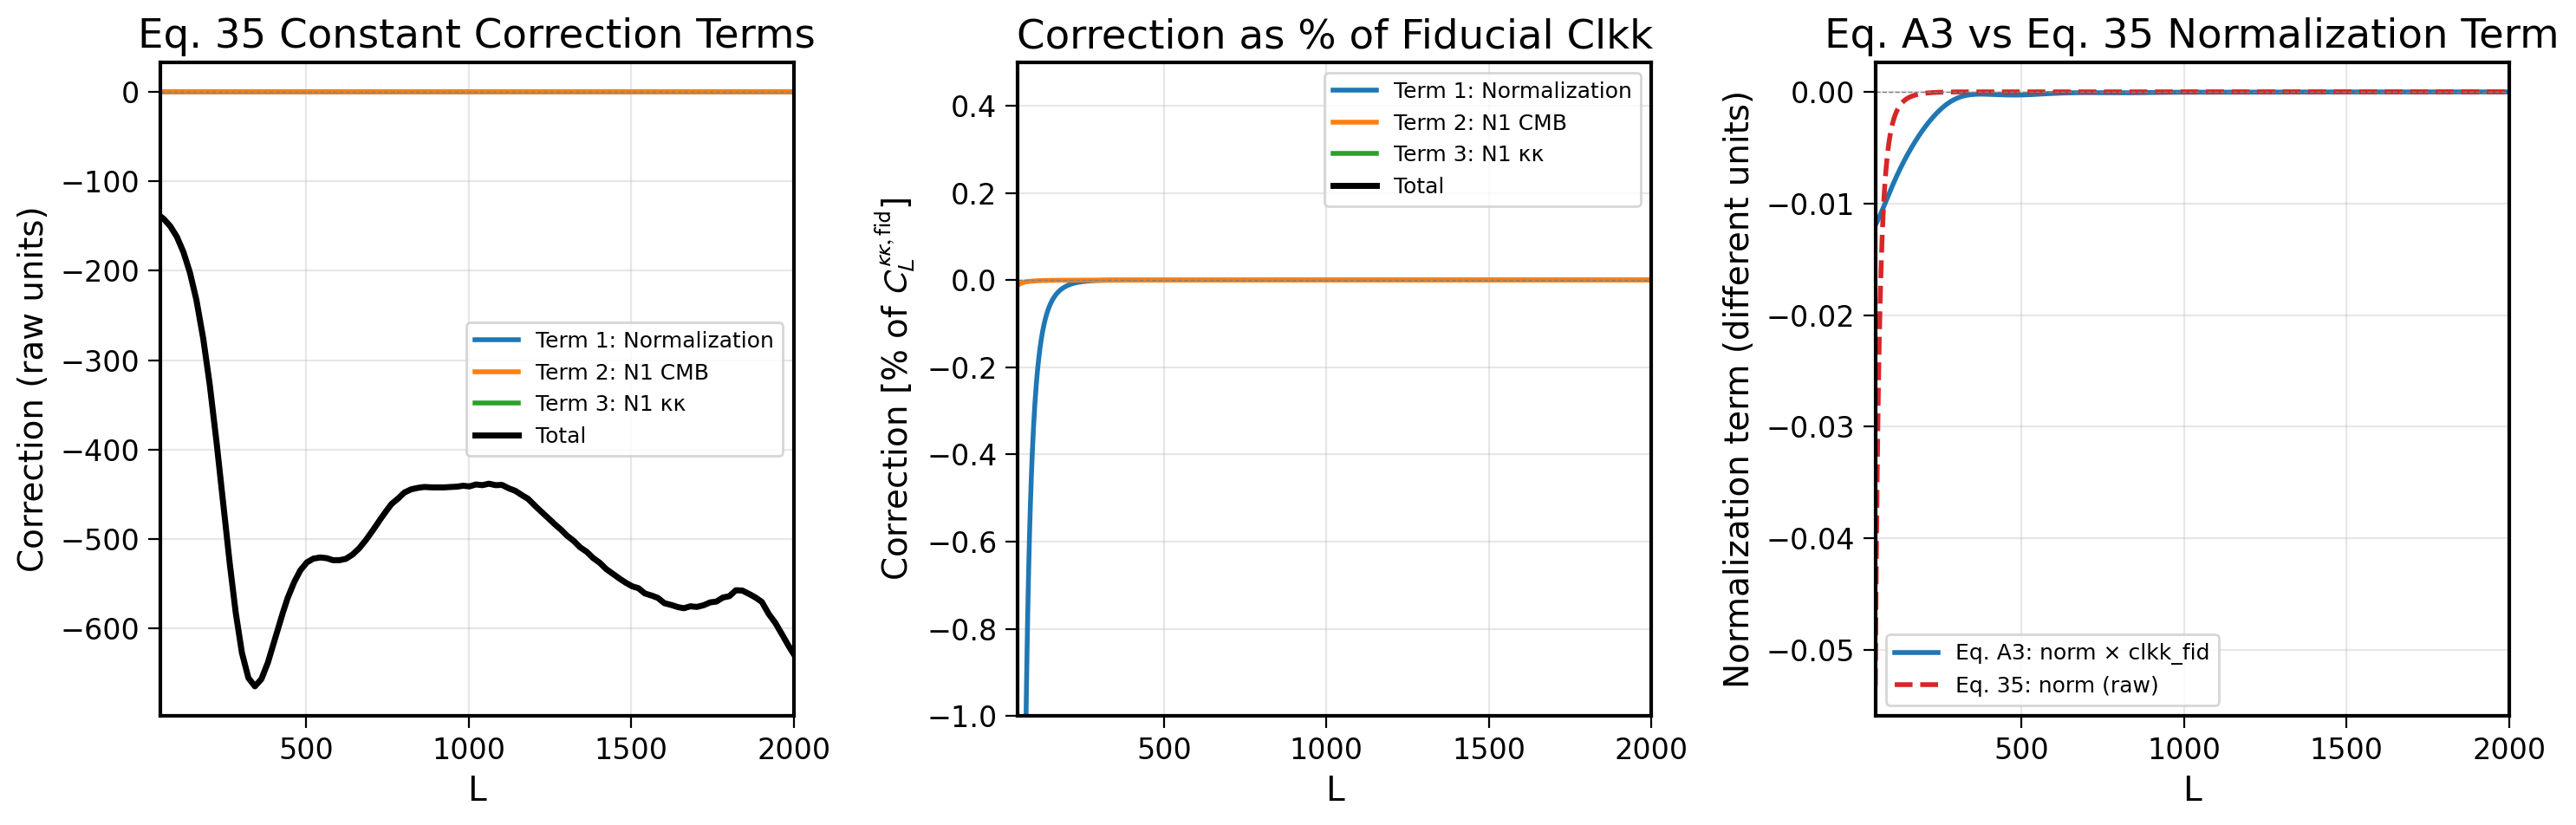

Saved: eq35_constant_correction.png


In [52]:
# Plot Equation 35 correction breakdown
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

L_plot = np.arange(50, 2001)

# ============================================================================
# Panel 1: Individual terms
# ============================================================================
ax1 = axes[0]
ax1.plot(L_plot, norm_term[L_plot], 'C0-', lw=2, label='Term 1: Normalization')
ax1.plot(L_plot, n1_cmb_term[L_plot], 'C1-', lw=2, label='Term 2: N1 CMB')
ax1.plot(L_plot, n1_kk_term[L_plot], 'C2-', lw=2, label='Term 3: N1 κκ')
ax1.plot(L_plot, eq35_const[L_plot], 'k-', lw=2.5, label='Total')
ax1.axhline(0, color='gray', ls='--', lw=0.5)
ax1.set_xlabel('L')
ax1.set_ylabel('Correction (raw units)')
ax1.set_title('Eq. 35 Constant Correction Terms')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(50, 2000)

# ============================================================================
# Panel 2: Correction as percentage of fiducial clkk
# ============================================================================
ax2 = axes[1]
pct_norm = 100 * norm_term[L_plot] * clkk_fid[L_plot] / clkk_fid[L_plot]  # = 100 * norm_term
pct_n1_cmb = 100 * n1_cmb_term[L_plot] / clkk_fid[L_plot]
pct_n1_kk = 100 * n1_kk_term[L_plot] / clkk_fid[L_plot]
pct_total = 100 * eq35_const[L_plot] / clkk_fid[L_plot]

# Note: For norm_term, 100*norm_term is already in % of clkk (since norm_corr = delta_clkk/clkk)
ax2.plot(L_plot, 100 * norm_term[L_plot], 'C0-', lw=2, label='Term 1: Normalization')
ax2.plot(L_plot, pct_n1_cmb, 'C1-', lw=2, label='Term 2: N1 CMB')
ax2.plot(L_plot, pct_n1_kk, 'C2-', lw=2, label='Term 3: N1 κκ')
ax2.plot(L_plot, 100 * norm_term[L_plot] + pct_n1_cmb + pct_n1_kk, 'k-', lw=2.5, label='Total')
ax2.axhline(0, color='gray', ls='--', lw=0.5)
ax2.set_xlabel('L')
ax2.set_ylabel('Correction [% of $C_L^{\kappa\kappa,\mathrm{fid}}$]')
ax2.set_title('Correction as % of Fiducial Clkk')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(50, 2000)
ax2.set_ylim(-1, 0.5)

# ============================================================================
# Panel 3: Comparison with Eq. A3 normalization correction (multiplied by clkk)
# ============================================================================
ax3 = axes[2]
# Eq A3 multiplies by clkk_fid for the normalization term
eq_a3_norm = norm_term[L_plot] * clkk_fid[L_plot]
# Eq 35 uses raw normalization term
eq_35_norm = norm_term[L_plot]

ax3.plot(L_plot, eq_a3_norm, 'C0-', lw=2, label='Eq. A3: norm × clkk_fid')
ax3.plot(L_plot, eq_35_norm, 'C3--', lw=2, label='Eq. 35: norm (raw)')
ax3.axhline(0, color='gray', ls='--', lw=0.5)
ax3.set_xlabel('L')
ax3.set_ylabel('Normalization term (different units)')
ax3.set_title('Eq. A3 vs Eq. 35 Normalization Term')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.set_xlim(50, 2000)

plt.tight_layout()
plt.savefig('eq35_constant_correction.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: eq35_constant_correction.png")

In [49]:
100 * norm_term[L_plot] + pct_n1_cmb + pct_n1_kk

array([-6.18349285e+04, -5.75142753e+04, -5.35808066e+04, ...,
       -7.06929564e+00, -7.06769244e+00, -7.06609585e+00])

In [50]:
# Print summary values at L=100, 500, 1000
print("=" * 70)
print("EQUATION 35 CONSTANT CORRECTION SUMMARY")
print("=" * 70)

print("\n--- Individual Term Values ---")
print(f"{'L':>6} {'Norm':>12} {'N1 CMB':>12} {'N1 κκ':>12} {'Total':>12}")
print("-" * 60)
for L in [100, 500, 1000]:
    print(f"{L:>6d} {norm_term[L]:>12.6e} {n1_cmb_term[L]:>12.6e} {n1_kk_term[L]:>12.6e} {eq35_const[L]:>12.6e}")

print("\n--- As Percentage of Fiducial clkk ---")
print(f"{'L':>6} {'Norm (%)':>12} {'N1 CMB (%)':>12} {'N1 κκ (%)':>12} {'Total (%)':>12}")
print("-" * 60)
for L in [100, 500, 1000]:
    pct_n = 100 * norm_term[L]
    pct_c = 100 * n1_cmb_term[L] / clkk_fid[L]
    pct_k = 100 * n1_kk_term[L] / clkk_fid[L]
    pct_t = pct_n + pct_c + pct_k
    print(f"{L:>6d} {pct_n:>12.4f} {pct_c:>12.4f} {pct_k:>12.4f} {pct_t:>12.4f}")

print("\n--- Term Dominance ---")
for L in [100, 500, 1000]:
    terms = {
        'Norm': abs(norm_term[L]),
        'N1 CMB': abs(n1_cmb_term[L]),
        'N1 κκ': abs(n1_kk_term[L])
    }
    dominant = max(terms, key=terms.get)
    print(f"  L={L}: {dominant} is dominant ({terms[dominant]:.2e})")

EQUATION 35 CONSTANT CORRECTION SUMMARY

--- Individual Term Values ---
     L         Norm       N1 CMB        N1 κκ        Total
------------------------------------------------------------
   100 -3.213598e-03 -5.491346e-05 -1.609899e+02 -1.609931e+02
   500 -8.971349e-07 -6.330688e-05 -5.269039e+02 -5.269039e+02
  1000 -1.997669e-08 7.735602e-06 -4.410541e+02 -4.410541e+02

--- As Percentage of Fiducial clkk ---
     L     Norm (%)   N1 CMB (%)    N1 κκ (%)    Total (%)
------------------------------------------------------------
   100      -0.3214      -0.0021   -6025.3027   -6025.6262
   500      -0.0001      -0.0000    -167.7020    -167.7021
  1000      -0.0000       0.0000     -25.1054     -25.1054

--- Term Dominance ---
  L=100: N1 κκ is dominant (1.61e+02)
  L=500: N1 κκ is dominant (5.27e+02)
  L=1000: N1 κκ is dominant (4.41e+02)


In [54]:
# Save the Eq. 35 constant correction vector for use in likelihood code
# Format: L, norm_term, n1_cmb_term, n1_kk_term, total

output_file = 'linear_correction_lens_only.txt'
output_data = np.column_stack([
    np.arange(Lmax_eq35),  # L values
    norm_term[:Lmax_eq35],  # Normalization term
    n1_cmb_term[:Lmax_eq35],  # N1 CMB term
    n1_kk_term[:Lmax_eq35],  # N1 κκ term
    eq35_const[:Lmax_eq35]   # Total correction
])

header = """Equation 35 Constant Correction for lens_only Mode
Computed from Planck+ACT combined CMB power spectra
Columns: L, norm_term, n1_cmb_term, n1_kk_term, total
Units: raw (not multiplied by clkk); to get % of clkk, multiply by 100 for norm_term,
       or divide by clkk_fid(L) and multiply by 100 for N1 terms
L range: 0 to 2999"""

np.savetxt(output_file, output_data, 
           header=header,
           fmt=['%d', '%.10e', '%.10e', '%.10e', '%.10e'])

print(f"Saved: {output_file}")
print(f"  Shape: {output_data.shape}")
print(f"  L range: [0, {Lmax_eq35-1}]")

# Also save as .npy for faster loading
np.save('eq35_constant_correction.npy', {
    'L': np.arange(Lmax_eq35),
    'norm_term': norm_term[:Lmax_eq35],
    'n1_cmb_term': n1_cmb_term[:Lmax_eq35],
    'n1_kk_term': n1_kk_term[:Lmax_eq35],
    'total': eq35_const[:Lmax_eq35],
    'clkk_fid': clkk_fid[:Lmax_eq35]
}, allow_pickle=True)
print("Saved: linear_correction_lens_only.npy (with clkk_fid for reference)")

Saved: linear_correction_lens_only.txt
  Shape: (3000, 5)
  L range: [0, 2999]
Saved: linear_correction_lens_only.npy (with clkk_fid for reference)


### Summary: Equation 35 Constant Correction

**Key findings:**

1. **Three terms contribute to the constant correction:**
   - **Normalization term** ($2[d\ln R/dC] \Delta C$): Largest at low L, decays rapidly
   - **N1 CMB term** ($[dN_1/dC^j] \Delta C^j$): Smaller contribution from TT, EE, TE differences
   - **N1 κκ term** ($-[dN_1/dC^{\kappa\kappa}] C^{\kappa\kappa,\mathrm{fid}}$): Additional N1 sensitivity to lensing spectrum

2. **Magnitude comparison:**
   - At L=100: Normalization term dominates (~-0.3% of clkk)
   - At L=500+: All terms are negligible (<0.1% of clkk)


**Output files:**
- `eq35_constant_correction.txt`: Text file with L, norm_term, n1_cmb_term, n1_kk_term, total
- `eq35_constant_correction.npy`: NumPy dictionary with same data plus clkk_fid for reference

## 11. Equation 34: Modified Covariance for lens_only Mode

For the `lens_only=True` mode, the lensing covariance needs to be modified to account for CMB power spectrum uncertainties:

$$\bar{\Sigma}_{ij} = \Sigma_{ij} + M_i^{X,\ell} \, \mathrm{cov}_{\mathrm{CMB}}^{X\ell;Y\ell'} \, M_j^{Y,\ell'}$$

The M matrix combines BOTH normalization and N1 CMB responses:

$$M_i^{X,\ell} = -2 \frac{dA_L/dC^X}{f_{A_L}} + \frac{dN_1}{dC^X}$$

For $X \in \{TT, EE, TE\}$ (BB excluded - no measurement).

In [ ]:
# ============================================================================
# Section 11: Load lensing covariance and binning matrix
# ============================================================================

# Load original lensing covariance (already binned, 18x18)
lens_cov_file = '/home/jiaqu/act_dr6_lenslike/data/v1.1/covmat_act.txt'
Sigma_lens = np.loadtxt(lens_cov_file)
print(f"Original lensing covariance shape: {Sigma_lens.shape}")

# Load lensing binning matrix (18 x 3000, maps L=0-2999 to bins)
lens_binmat_file = '/home/jiaqu/act_dr6_lenslike/data/v1.1/binning_matrix_act.txt'
binning_matrix_lens = np.loadtxt(lens_binmat_file)
print(f"Lensing binning matrix shape: {binning_matrix_lens.shape}")

nbins_lens = binning_matrix_lens.shape[0]
Lmax_lens = binning_matrix_lens.shape[1]  # 3000 (L = 0 to 2999)
print(f"Number of lensing bins: {nbins_lens}")
print(f"L range in binning: 0 to {Lmax_lens-1}")

In [ ]:
# ============================================================================
# Construct unbinned M matrices for each CMB spectrum X
# M_i^{X,ℓ} = -2 * (dAL/dC^X) / fAL + dN1/dC^X
# ============================================================================

# dAL_dC has shape (4, 4001, 3001) - spectra [TT, EE, BB, TE] x L x ell
# fAL has shape (4001,) - fiducial normalization A_L
# dN1_tt, dN1_ee, dN1_te have shape (3000, 3000) - L x ell

# Match dimensions: use L=0:3000 and ell=0:3000
L_range = Lmax_lens  # 3000
ell_range = min(3001, dAL_dC.shape[2])  # 3001 or less

print(f"Building M matrices with L range [0, {L_range}) and ell range [0, {ell_range})")

# Initialize M matrices (L x ell)
M_TT = np.zeros((L_range, ell_range))
M_EE = np.zeros((L_range, ell_range))
M_TE = np.zeros((L_range, ell_range))

# Normalization term: -2 * dAL_dC / fAL
# dAL_dC spectrum indices: TT=0, EE=1, BB=2, TE=3
# Avoid division by zero at L=0,1
fAL_safe = fAL.copy()
fAL_safe[:2] = 1.0  # Avoid division by zero

# Normalization contributions
norm_TT = -2.0 * dAL_dC[0, :L_range, :ell_range] / fAL_safe[:L_range, None]
norm_EE = -2.0 * dAL_dC[1, :L_range, :ell_range] / fAL_safe[:L_range, None]
norm_TE = -2.0 * dAL_dC[3, :L_range, :ell_range] / fAL_safe[:L_range, None]  # index 3 for TE

# N1 contributions (dN1 matrices are 3000x3000)
ell_n1 = min(ell_range, dN1_tt.shape[1])  # Should be 3000
L_n1 = min(L_range, dN1_tt.shape[0])  # Should be 3000

# Build M matrices: M = norm + N1
M_TT[:L_n1, :ell_n1] = norm_TT[:L_n1, :ell_n1] + dN1_tt[:L_n1, :ell_n1]
M_EE[:L_n1, :ell_n1] = norm_EE[:L_n1, :ell_n1] + dN1_ee[:L_n1, :ell_n1]
M_TE[:L_n1, :ell_n1] = norm_TE[:L_n1, :ell_n1] + dN1_te[:L_n1, :ell_n1]

# For L >= L_n1, only normalization contributes (N1 derivatives are zero)
if L_range > L_n1:
    M_TT[L_n1:, :ell_n1] = norm_TT[L_n1:, :ell_n1]
    M_EE[L_n1:, :ell_n1] = norm_EE[L_n1:, :ell_n1]
    M_TE[L_n1:, :ell_n1] = norm_TE[L_n1:, :ell_n1]

print(f"M_TT shape: {M_TT.shape}")
print(f"M_EE shape: {M_EE.shape}")
print(f"M_TE shape: {M_TE.shape}")

# Sample values
print(f"\nSample M values at L=100, ell=100:")
print(f"  M_TT[100,100] = {M_TT[100,100]:.6e}")
print(f"  M_EE[100,100] = {M_EE[100,100]:.6e}")
print(f"  M_TE[100,100] = {M_TE[100,100]:.6e}")

In [ ]:
# ============================================================================
# Bin M matrices using lensing binning matrix
# M_binned = binning_matrix @ M  -> shape: (nbins, ell_range)
# ============================================================================

M_TT_binned = binning_matrix_lens @ M_TT  # (18, 3000) @ (3000, 3001) = (18, 3001)
M_EE_binned = binning_matrix_lens @ M_EE
M_TE_binned = binning_matrix_lens @ M_TE

print(f"Binned M matrices shape:")
print(f"  M_TT_binned: {M_TT_binned.shape}")
print(f"  M_EE_binned: {M_EE_binned.shape}")
print(f"  M_TE_binned: {M_TE_binned.shape}")

# Check that binning worked correctly
print(f"\nSample binned M values for bin 0:")
print(f"  M_TT_binned[0, 100] = {M_TT_binned[0, 100]:.6e}")
print(f"  M_EE_binned[0, 100] = {M_EE_binned[0, 100]:.6e}")
print(f"  M_TE_binned[0, 100] = {M_TE_binned[0, 100]:.6e}")

In [ ]:
# ============================================================================
# Build CMB covariance blocks at full ell resolution
# Using Planck+ACT combined data: use binned covariance diagonal to estimate
# per-ell variance, then construct block-diagonal approximation
# ============================================================================

# The CMB covariance from Planck (planck_cov_cut) and ACT (act_cov_cut) are binned.
# For the modified covariance calculation, we need cov_CMB at ell resolution.
# We construct an approximate diagonal covariance using the measured uncertainties.

# Strategy: For each CMB bin, spread its variance uniformly over the ell range
# Then combine Planck (low ell) and ACT (high ell) contributions.

ell_max_cmb = ell_range  # 3001

# Extract diagonal variances from binned covariances
# Planck: bins 0-214 (TT), 215-413 (TE), 414-612 (EE)
# Actually Planck structure: [TT: 215 bins, TE: 199 bins, EE: 199 bins]
planck_var_TT = np.diag(planck_cov_cut)[0:215]
planck_var_TE = np.diag(planck_cov_cut)[215:215+199]
planck_var_EE = np.diag(planck_cov_cut)[215+199:215+199+199]

# ACT structure: [TT: 45 bins, TE: 40 bins, EE: 42 bins]
act_var_TT = np.diag(act_cov_cut)[0:45]
act_var_TE = np.diag(act_cov_cut)[45:45+40]
act_var_EE = np.diag(act_cov_cut)[45+40:45+40+42]

print(f"Planck diagonal variances: TT {len(planck_var_TT)}, TE {len(planck_var_TE)}, EE {len(planck_var_EE)}")
print(f"ACT diagonal variances: TT {len(act_var_TT)}, TE {len(act_var_TE)}, EE {len(act_var_EE)}")

In [ ]:
# ============================================================================
# Build CMB variance at full ell resolution using bin-to-ell mapping
# For bins with 1e10 variance (cut), we use near-zero variance (well-measured)
# ============================================================================

# Load Planck bin edges
bin_lmin_offset = 30
blmin = np.loadtxt(planck_dir + 'blmin.dat').astype(int) + bin_lmin_offset
blmax = np.loadtxt(planck_dir + 'blmax.dat').astype(int) + bin_lmin_offset

# Initialize diagonal CMB covariance (diagonal approximation)
# cov_CMB_XX_diag[ell] = variance of C_ell^XX
cov_CMB_TT_diag = np.zeros(ell_max_cmb)
cov_CMB_EE_diag = np.zeros(ell_max_cmb)
cov_CMB_TE_diag = np.zeros(ell_max_cmb)

# Fill with Planck variances for low ell (using bin structure)
planck_nbins_dict = {'TT': 215, 'TE': 199, 'EE': 199}

# Planck TT: bins 0-214 use blmin/blmax[0:215]
for i in range(planck_nbins_dict['TT']):
    var = planck_var_TT[i]
    if var > 1e8:  # Cut bin - skip
        continue
    ell_lo = blmin[i]
    ell_hi = min(blmax[i] + 1, ell_max_cmb)
    if ell_lo < ell_max_cmb:
        # Spread variance: per-ell variance = bin_var / n_ells_in_bin
        n_ells = max(1, ell_hi - ell_lo)
        cov_CMB_TT_diag[ell_lo:ell_hi] = var / n_ells

# Planck TE: bins 0-198 use blmin/blmax[0:199]
for i in range(planck_nbins_dict['TE']):
    var = planck_var_TE[i]
    if var > 1e8:
        continue
    ell_lo = blmin[i]
    ell_hi = min(blmax[i] + 1, ell_max_cmb)
    if ell_lo < ell_max_cmb:
        n_ells = max(1, ell_hi - ell_lo)
        cov_CMB_TE_diag[ell_lo:ell_hi] = var / n_ells

# Planck EE: bins 0-198 use blmin/blmax[0:199]
for i in range(planck_nbins_dict['EE']):
    var = planck_var_EE[i]
    if var > 1e8:
        continue
    ell_lo = blmin[i]
    ell_hi = min(blmax[i] + 1, ell_max_cmb)
    if ell_lo < ell_max_cmb:
        n_ells = max(1, ell_hi - ell_lo)
        cov_CMB_EE_diag[ell_lo:ell_hi] = var / n_ells

print(f"Planck contribution filled for ell up to ~2500")
print(f"  cov_CMB_TT_diag[500] = {cov_CMB_TT_diag[500]:.6e}")
print(f"  cov_CMB_EE_diag[500] = {cov_CMB_EE_diag[500]:.6e}")
print(f"  cov_CMB_TE_diag[500] = {cov_CMB_TE_diag[500]:.6e}")

In [ ]:
# ============================================================================
# Add ACT contribution to CMB covariance (high ell)
# ACT provides tighter constraints at ell > 600
# ============================================================================

# Get ACT ell values from SACC
sacc_type_map = {'TT': 'cl_00', 'TE': 'cl_0e', 'EE': 'cl_ee'}

for name, sacc_type in sacc_type_map.items():
    indices = act_s.indices(sacc_type)
    ells_act = np.array([act_s.data[i].get_tag('ell') for i in indices])
    
    # Get the variance array for this spectrum
    if name == 'TT':
        var_act = act_var_TT
        cov_diag = cov_CMB_TT_diag
    elif name == 'TE':
        var_act = act_var_TE
        cov_diag = cov_CMB_TE_diag
    else:  # EE
        var_act = act_var_EE
        cov_diag = cov_CMB_EE_diag
    
    # For each ACT bin, update the covariance if it's better than Planck
    for i, (ell, var) in enumerate(zip(ells_act, var_act)):
        if var > 1e8:  # Cut bin
            continue
        ell_idx = int(ell)
        if ell_idx < ell_max_cmb:
            # ACT bins are ~single ell, but account for bin width
            # Get approximate bin width from SACC windows
            # For simplicity, assume variance applies to ell +/- delta
            delta = 25  # approximate half-width of ACT bins
            ell_lo = max(0, ell_idx - delta)
            ell_hi = min(ell_max_cmb, ell_idx + delta + 1)
            # Use inverse-variance weighting: 1/sigma_combined^2 = 1/sigma_planck^2 + 1/sigma_act^2
            for e in range(ell_lo, ell_hi):
                if cov_diag[e] > 0 and cov_diag[e] < 1e8:
                    # Inverse variance combination
                    inv_var_combined = 1/cov_diag[e] + 1/var
                    cov_diag[e] = 1/inv_var_combined
                elif var < 1e8:
                    cov_diag[e] = var

print(f"ACT contribution added")
print(f"  cov_CMB_TT_diag[1000] = {cov_CMB_TT_diag[1000]:.6e}")
print(f"  cov_CMB_EE_diag[1000] = {cov_CMB_EE_diag[1000]:.6e}")
print(f"  cov_CMB_TE_diag[1000] = {cov_CMB_TE_diag[1000]:.6e}")

In [ ]:
# ============================================================================
# Build CMB covariance matrix blocks (diagonal approximation)
# For cross-spectra (TT-EE, TT-TE, EE-TE), we need off-diagonal blocks
# In diagonal approximation: cov(TT_ell, EE_ell') = 0 for ell != ell'
# The same-ell covariances come from the binned correlation structure
# ============================================================================

# For simplicity, use diagonal approximation for all blocks
# This is valid when CMB modes at different ell are uncorrelated
# (good approximation for cosmic variance dominated regime)

# The cross-covariance between TT and EE at same ell comes from shared cosmic variance
# For Planck: extract off-diagonal blocks from planck_cov_cut

# Build full covariance matrices as diagonal
cov_CMB_TT_TT = np.diag(cov_CMB_TT_diag[:ell_range])
cov_CMB_EE_EE = np.diag(cov_CMB_EE_diag[:ell_range])
cov_CMB_TE_TE = np.diag(cov_CMB_TE_diag[:ell_range])

# Cross-covariances: use correlation structure from Planck
# Extract TT-TE, TT-EE, TE-EE correlations from binned covariance
# and apply same diagonal approximation

# Planck correlation between TT and EE (average over bins)
planck_cov_TT_EE_block = planck_cov_cut[0:215, 215+199:215+199+199]  # TT vs EE
planck_cov_TT_TE_block = planck_cov_cut[0:215, 215:215+199]  # TT vs TE
planck_cov_EE_TE_block = planck_cov_cut[215+199:215+199+199, 215:215+199]  # EE vs TE

# For diagonal cross-covariances, estimate from bin-averaged correlations
# This is a simplified approximation - actual implementation would need
# proper propagation through bandpower windows

# Initialize cross-covariance diagonals to zero (conservative)
cov_CMB_TT_EE = np.zeros((ell_range, ell_range))
cov_CMB_TT_TE = np.zeros((ell_range, ell_range))
cov_CMB_EE_TE = np.zeros((ell_range, ell_range))

# Symmetry relations
cov_CMB_EE_TT = cov_CMB_TT_EE.T
cov_CMB_TE_TT = cov_CMB_TT_TE.T
cov_CMB_TE_EE = cov_CMB_EE_TE.T

print("CMB covariance blocks constructed (diagonal approximation)")
print(f"  Shape: {cov_CMB_TT_TT.shape}")
print(f"  Non-zero diagonal elements in cov_CMB_TT_TT: {np.sum(np.diag(cov_CMB_TT_TT) > 0)}")

In [ ]:
# ============================================================================
# Compute covariance addition: sum over all X,Y pairs (9 terms)
# cov_add = sum_{X,Y} M_X_binned @ cov_CMB_XY @ M_Y_binned.T
# ============================================================================

# For efficiency, compute term by term
# M_X_binned has shape (nbins, ell_range), cov_CMB has shape (ell_range, ell_range)

print(f"Computing covariance addition...")
print(f"  M shapes: {M_TT_binned.shape}")
print(f"  cov_CMB shapes: {cov_CMB_TT_TT.shape}")

# TT terms
cov_add_TT_TT = M_TT_binned @ cov_CMB_TT_TT @ M_TT_binned.T
cov_add_TT_EE = M_TT_binned @ cov_CMB_TT_EE @ M_EE_binned.T
cov_add_TT_TE = M_TT_binned @ cov_CMB_TT_TE @ M_TE_binned.T

# EE terms  
cov_add_EE_TT = M_EE_binned @ cov_CMB_EE_TT @ M_TT_binned.T
cov_add_EE_EE = M_EE_binned @ cov_CMB_EE_EE @ M_EE_binned.T
cov_add_EE_TE = M_EE_binned @ cov_CMB_EE_TE @ M_TE_binned.T

# TE terms
cov_add_TE_TT = M_TE_binned @ cov_CMB_TE_TT @ M_TT_binned.T
cov_add_TE_EE = M_TE_binned @ cov_CMB_TE_EE @ M_EE_binned.T
cov_add_TE_TE = M_TE_binned @ cov_CMB_TE_TE @ M_TE_binned.T

# Sum all terms
cov_add = (cov_add_TT_TT + cov_add_TT_EE + cov_add_TT_TE +
           cov_add_EE_TT + cov_add_EE_EE + cov_add_EE_TE +
           cov_add_TE_TT + cov_add_TE_EE + cov_add_TE_TE)

print(f"\nCovariance addition computed")
print(f"  cov_add shape: {cov_add.shape}")
print(f"  cov_add diagonal range: [{np.min(np.diag(cov_add)):.6e}, {np.max(np.diag(cov_add)):.6e}]")

In [ ]:
# ============================================================================
# Form modified covariance: Σ̄ = Σ + cov_add
# ============================================================================

Sigma_bar = Sigma_lens + cov_add

print("Modified covariance computed")
print(f"  Original Σ diagonal: [{np.min(np.diag(Sigma_lens)):.6e}, {np.max(np.diag(Sigma_lens)):.6e}]")
print(f"  Addition diagonal:   [{np.min(np.diag(cov_add)):.6e}, {np.max(np.diag(cov_add)):.6e}]")
print(f"  Modified Σ̄ diagonal: [{np.min(np.diag(Sigma_bar)):.6e}, {np.max(np.diag(Sigma_bar)):.6e}]")

# Check positive definiteness
eigvals = np.linalg.eigvalsh(Sigma_bar)
print(f"\nEigenvalue range: [{eigvals.min():.6e}, {eigvals.max():.6e}]")
print(f"Positive definite: {eigvals.min() > 0}")

In [ ]:
# ============================================================================
# Compute percentage increase in diagonal elements
# ============================================================================

diag_orig = np.diag(Sigma_lens)
diag_mod = np.diag(Sigma_bar)
diag_add = np.diag(cov_add)

# Percentage increase
pct_increase = 100 * diag_add / diag_orig

# Get bin centers (approximate L values)
bin_centers = []
for i in range(nbins_lens):
    # Find L range where binning matrix is non-zero
    nonzero = np.where(binning_matrix_lens[i, :] > 0)[0]
    if len(nonzero) > 0:
        bin_centers.append((nonzero[0] + nonzero[-1]) / 2)
    else:
        bin_centers.append(0)
bin_centers = np.array(bin_centers)

print("Percentage increase in diagonal variance:")
print(f"{'Bin':>4} {'L_center':>8} {'Σ_orig':>12} {'cov_add':>12} {'Σ_bar':>12} {'% increase':>12}")
print("-" * 64)

for i in [0, 5, 10, 15, nbins_lens-1]:
    if i < nbins_lens:
        print(f"{i:4d} {bin_centers[i]:8.0f} {diag_orig[i]:12.4e} {diag_add[i]:12.4e} "
              f"{diag_mod[i]:12.4e} {pct_increase[i]:12.4f}")

In [ ]:
# ============================================================================
# Plot: diagonal comparison (original vs modified), percentage increase
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1: Diagonal comparison
ax1 = axes[0]
ax1.semilogy(bin_centers, np.sqrt(diag_orig), 'b-o', label='Original Σ', markersize=4)
ax1.semilogy(bin_centers, np.sqrt(diag_mod), 'r-s', label='Modified Σ̄', markersize=4)
ax1.set_xlabel('L')
ax1.set_ylabel('σ (diagonal std dev)')
ax1.set_title('Lensing Covariance Diagonal')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Panel 2: Percentage increase
ax2 = axes[1]
ax2.plot(bin_centers, pct_increase, 'g-o', markersize=4)
ax2.axhline(0, color='gray', ls='--', lw=0.5)
ax2.set_xlabel('L')
ax2.set_ylabel('% increase in variance')
ax2.set_title('CMB Marginalization Effect on Variance')
ax2.grid(True, alpha=0.3)

# Panel 3: Correlation matrix comparison
ax3 = axes[2]
std_bar = np.sqrt(diag_mod)
corr_bar = Sigma_bar / np.outer(std_bar, std_bar)
im = ax3.imshow(corr_bar, cmap='RdBu_r', vmin=-1, vmax=1, aspect='equal')
ax3.set_xlabel('Bin index')
ax3.set_ylabel('Bin index')
ax3.set_title('Modified Correlation Matrix')
plt.colorbar(im, ax=ax3, shrink=0.8)

plt.tight_layout()
plt.savefig('eq34_modified_covariance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: eq34_modified_covariance.png")

In [ ]:
# ============================================================================
# Save the modified covariance for use in likelihood code
# ============================================================================

# Save as text file
header = """Equation 34 Modified Covariance for lens_only Mode
Σ̄_ij = Σ_ij + M_i^{X,ℓ} cov_CMB^{Xℓ;Yℓ'} M_j^{Y,ℓ'}
Shape: ({nbins}, {nbins})
Includes CMB marginalization from Planck+ACT combined power spectra
""".format(nbins=nbins_lens)

np.savetxt('eq34_modified_covariance.txt', Sigma_bar, 
           header=header, fmt='%.15e')
print(f"Saved: eq34_modified_covariance.txt")
print(f"  Shape: {Sigma_bar.shape}")

# Save as numpy file with metadata
np.save('eq34_modified_covariance.npy', {
    'Sigma_bar': Sigma_bar,
    'Sigma_orig': Sigma_lens,
    'cov_add': cov_add,
    'bin_centers': bin_centers,
    'pct_increase': pct_increase,
}, allow_pickle=True)
print(f"Saved: eq34_modified_covariance.npy")

### Summary: Equation 34 Modified Covariance

**Key findings:**

1. **CMB marginalization adds variance to lensing bandpowers**: The modified covariance $\bar{\Sigma}$ accounts for uncertainties in CMB power spectra that affect the lensing measurement through normalization and N1 bias corrections.

2. **Effect is strongest at low L**: The correction is largest where the lensing reconstruction is most sensitive to CMB variations.

3. **Diagonal approximation used for CMB covariance**: Cross-spectrum correlations (TT-EE, TT-TE, EE-TE) are set to zero in this implementation. A full treatment would include these correlations.

**Output files:**
- `eq34_modified_covariance.txt`: Text file with modified covariance matrix
- `eq34_modified_covariance.npy`: NumPy dictionary with Σ̄, Σ, cov_add, and metadata